# Preparation

In [436]:
# %matplotlib widget
# %config InlineBackend.figure_format = 'svg'

import os, math
from enum import IntEnum, auto
from collections import defaultdict, namedtuple, Counter, deque
from dataclasses import dataclass
from heapq import heapify, heappush, heappop
import itertools
import sqlite3
import pickle
import datetime
import queue
import json
import copy
from IPython.core.getipython import get_ipython

from PIL import Image, ImageDraw
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec

import scipy as sp
import numpy as np
import cupy as cp
import pandas as pd
from sklearn.preprocessing import StandardScaler

import sys
sys.path.append('../../lib')

from utils import *
from shared_types import SensorInstance

In [2]:
LOG = Logging()

config_var = 'SQLITE3_SEQ_GRID_0_2_4096'
config = Config(config_var)
# RNG = np.random.default_rng() 
RNG = np.random.default_rng(42)

if cp.cuda.is_available():
    xp = cp.get_array_module(cp.empty(1))
    xp_array_from_gpu = lambda a: a.get() if isinstance(a, cp.ndarray) else a
    xp_array_to_gpu = lambda a: cp.asarray(a) if isinstance(a, np.ndarray) else a
    xp_array_to_gpu_copy = lambda a: cp.asarray(a) if isinstance(a, np.ndarray) else a
else:
    xp = cp.get_array_module(np.empty(1))
    xp_array_from_gpu = lambda a: a
    xp_array_to_gpu = lambda a: a
    xp_array_to_gpu_copy = lambda a: a.copy()

print(f'xp={xp.__name__}')

with open(get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
    notebook_fname = json.load(cf)['jupyter_session']
    notebook_fname = os.path.basename(notebook_fname)

print(f'notebook={notebook_fname}')
LOG.app_name = os.path.splitext(notebook_fname)[0].upper()

xp=numpy
notebook=gp_test.ipynb


# Data Loading

In [3]:
%time
train_db_con = sqlite3.connect(DBUtils.get_full_db_file_name(config, config.train_db_file_name))

CPU times: user 3 μs, sys: 0 ns, total: 3 μs
Wall time: 5.01 μs


In [4]:
df_train_images = pd.read_sql_query('SELECT * FROM images', con=train_db_con, index_col='image_id')
df_train_images.shape

(10000, 7)

In [5]:
fetch_si_xy = lambda si: (si.x, si.y)
get_joint_sequence = lambda sequences: np.array(list(itertools.chain.from_iterable(sequences)))
get_sequences_reading = lambda sequences, seq_reading_code: list(map(lambda r: sequences[r[0]] if r[1] == 0 else list(reversed(sequences[r[0]])), seq_reading_code))
get_xy_sequence = lambda sequence, si_ind_dict: np.array(list(map(lambda si_ind: fetch_si_xy(si_ind_dict[si_ind]), sequence)))
get_raw_image = lambda image_id: Image.open(io.BytesIO((df_train_images if image_id < 100_000_000 else df_test_images).loc[image_id]['png']))


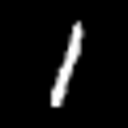
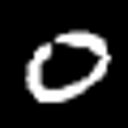
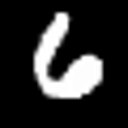
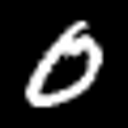
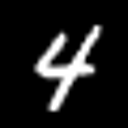
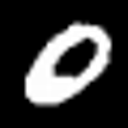
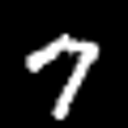
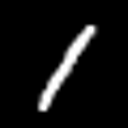

In [6]:
count = 8

def get_images_and_labels(df, ids):
    image_datas = df.loc[ids]['png']
    images = [Image.open(io.BytesIO(image_data)) for image_data in image_datas]
    labels = df.loc[ids]['value']
    return images, list(labels)

def get_some_random_images_and_labels(df, count):
    image_ids = RNG.choice(df.index.unique(), count, replace=False)
    return get_images_and_labels(df, image_ids)

train_images, train_labels = get_some_random_images_and_labels(df_train_images, count)

display_images_grid(train_images, captions=train_labels, col_count=count)

In [7]:
image = df_train_images[df_train_images.value == '5'].iloc[1]
sequences = pickle.loads(image.inner_sequences)
si_ind_dict = pickle.loads(image.inner_si_ind_dict)

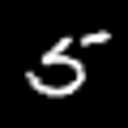

In [8]:
get_raw_image(image.name)

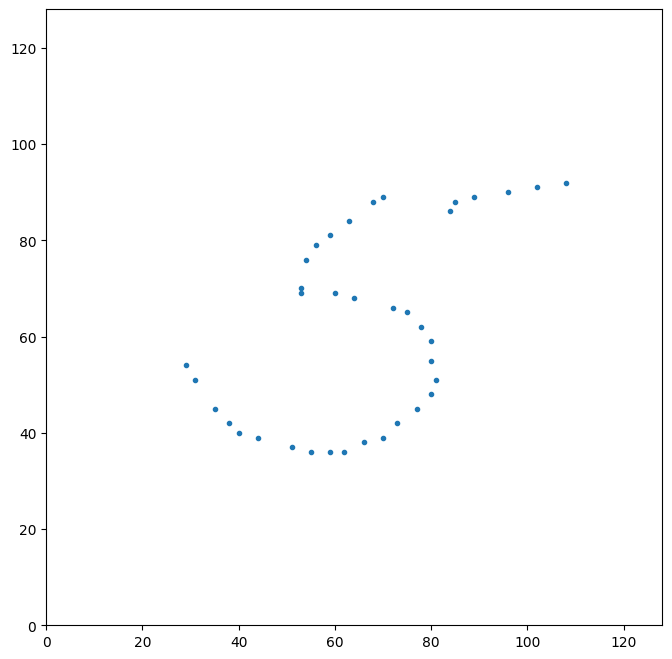

In [9]:
xy_list = get_xy_sequence(get_joint_sequence(sequences), si_ind_dict)

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
ax1.scatter(xy_list[:,0], config.sample_size - xy_list[:,1], marker='.')
ax1.set_aspect('equal')
ax1.set(xlim=(0, config.sample_size), ylim=(0, config.sample_size));

In [10]:
center_pos = config.sample_size / 2
data = []

for seq in sequences:
    for si_ind_from, si_ind_to in zip(seq[:-1], seq[1:]):
        si_from = si_ind_dict[si_ind_from]
        si_to = si_ind_dict[si_ind_to]
        # -si_to.y + si_from.y == config.sample_size - si_to.y - (config.sample_size - si_from.y)
        data.append((
            si_from.x,
            config.sample_size - si_from.y, 
            # complex(si_to.x - si_from.x, -si_to.y + si_from.y),
            si_to.x - si_from.x,
            -si_to.y + si_from.y
        ))

data = np.array(data, dtype='f')
data[:,0] -= center_pos
data[:,1] -= center_pos
data /= config.sample_size
np.round(data[:5], decimals=2)

array([[-0.09,  0.05,  0.01,  0.05],
       [-0.08,  0.09,  0.02,  0.02],
       [-0.06,  0.12,  0.02,  0.02],
       [-0.04,  0.13,  0.03,  0.02],
       [-0.01,  0.16,  0.04,  0.03]], dtype=float32)

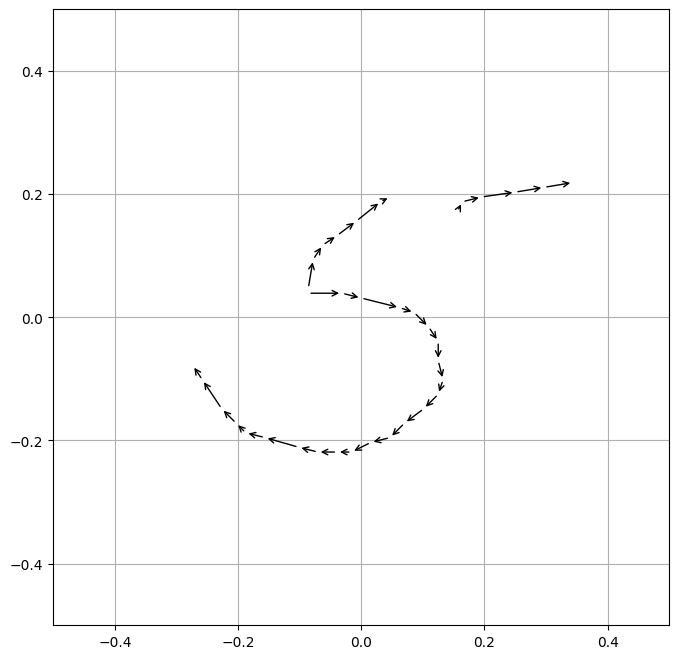

In [11]:
fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
ax1.set_aspect('equal')
ax1.grid(True)
ax1.set(xlim=(-.5, .5), ylim=(-.5, .5));

for item in data:
    x_from, y_from = item[0], item[1]
    x_to, y_to = x_from + item[2], y_from + item[3]
    # x_from, y_from = item[0].real, item[1].real
    # x_to, y_to = x_from + item[2].real, y_from + item[2].imag
    ax1.annotate('', xytext=(x_from, y_from), xy=(x_to, y_to), arrowprops=dict(arrowstyle="->"))

# ax1.set(xlim=(0, config.sample_size), ylim=(0, config.sample_size));

# for seq in sequences:
#     for si_ind_from, si_ind_to in zip(seq[:-1], seq[1:]):
#         si_from = si_ind_dict[si_ind_from]
#         si_to = si_ind_dict[si_ind_to]
#         # x = (si_from.x + si_to.x) / 2
#         # y = config.sample_size - (si_from.y + si_to.y) / 2
#         # ax1.scatter(x, y, marker='.', color='C0')
#         ax1.annotate('', xytext=(si_from.x, config.sample_size - si_from.y), xy=(si_to.x, config.sample_size - si_to.y), arrowprops=dict(arrowstyle="->"))

# Brutefoce GP

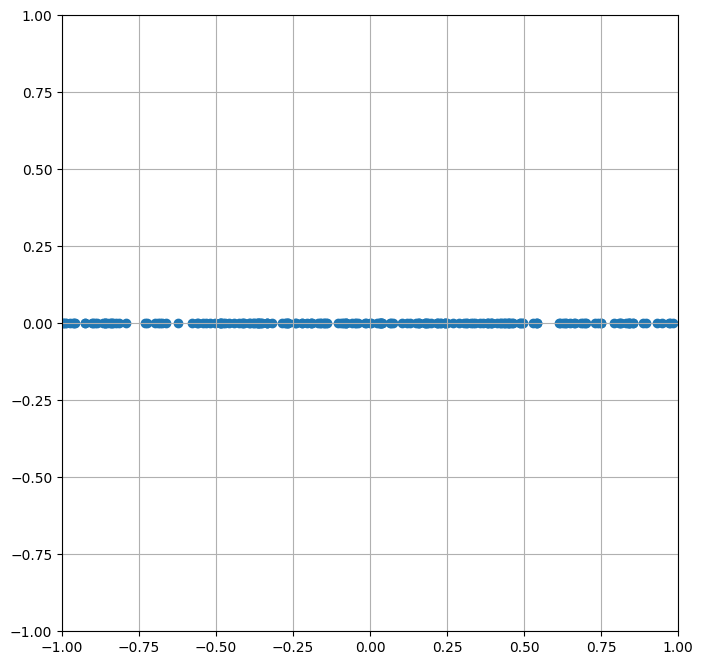

In [12]:
# Multimodal normal distribution
base_cov_mat = np.array([
    [1, 0],
    [0, 1],
])

scale_mat = np.array([[1, 0], [0, 1e-6]])
# scale_mat = np.eye(2)

def get_rot_mat(degrees):
    theta = np.deg2rad(degrees)
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

rot_mat = get_rot_mat(0)
cov_mat1 = rot_mat @ scale_mat @ scale_mat @ rot_mat.T

rot_mat = get_rot_mat(130)
cov_mat2 = rot_mat @ scale_mat @ scale_mat @ rot_mat.T

cov_mat = np.zeros((cov_mat1.shape[0] + cov_mat2.shape[0], cov_mat1.shape[0] + cov_mat2.shape[0]))
base_i, base_j = 0, 0
cov_mat[base_i:base_i+cov_mat1.shape[0], base_j:base_j+cov_mat1.shape[1]] = cov_mat1
base_i, base_j = cov_mat1.shape
cov_mat[base_i:base_i+cov_mat2.shape[0], base_j:base_j+cov_mat2.shape[1]] = cov_mat2

samples_count = 300

ys = RNG.multivariate_normal(
    mean=np.zeros(cov_mat.shape[0]),
    cov=cov_mat,
    size=samples_count)

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
ax1.scatter(ys[:,0], ys[:,1], color='C0')
# ax1.scatter(ys[:,2], ys[:,3], color='C1')
#im = ax1.imshow(ys.reshape(samples_count, -1), origin='lower')
# ax1.set_xlim(-.5, .5)
# ax1.set_ylim(-.5, .5)
# ax1.set_xticks(np.linspace(0, 29, 30))
# ax1.set_yticks(np.linspace(0, 29, 30))
ax1.set_xlim(-1, 1)
ax1.set_ylim(-1, 1)
ax1.set_aspect('equal')
ax1.grid()
# fig.colorbar(im, shrink=0.8, ax=ax1);

In [13]:
# Define the exponentiated quadratic 
def exponentiated_quadratic_kernel(xa, xb, ls=1):
    """Exponentiated quadratic with σ=1"""
    # L2 distance (Squared Euclidian)
    sq_norm = -sp.spatial.distance.cdist(xa, xb, 'sqeuclidean') / (2 * ls**2)
    return np.exp(sq_norm)

In [14]:
def linear_kernel(xa, xb, c=0, sigma_b=1, sigma_v=1):
    '''
    1) The offset "c" determines the x-coordinate of the point that all the lines
    in the posterior go though. At this point, the function will have zero
    variance (unless you add noise)
    2) The constant variance "sigma_b" determines how far from 0 the height of the
    function will be at zero. It's a little confusing, becuase it's not
    specifying that value directly, but rather putting a prior on it. It's
    equivalent to adding an uncertain offset to our model.
    3) The constant variance "sigma_v" is a prior on a slope.
    '''
    dist_func = lambda a, b: (sigma_b ** 2) + (sigma_v ** 2) * (a - c) @ (b - c)
    return sp.spatial.distance.cdist(xa, xb, dist_func)
    # return (sigma_b ** 2) + (sigma_v ** 2) * (xa - c) * (xb - c)

CPU times: user 2.84 s, sys: 30.6 ms, total: 2.87 s
Wall time: 262 ms


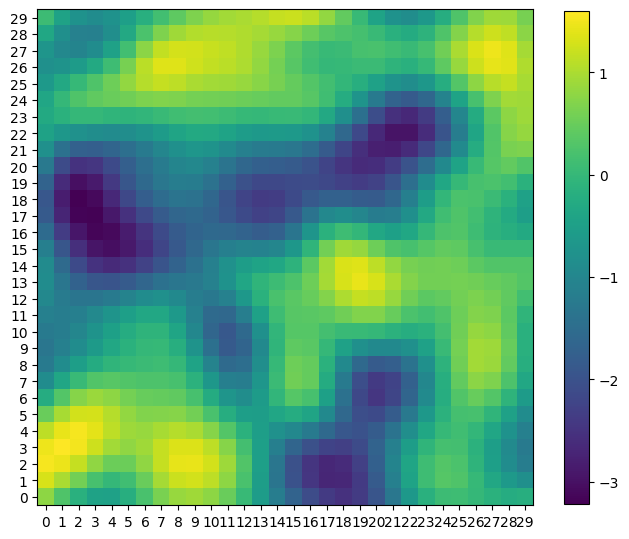

In [15]:
%%time
# Мы тут рассматриваем 2-х мерный случай: (x,y) -> значение пикселя grayscale (или on/off для BW).
# А это значит, что мы должны рассмотреть каждое сочетание из 30-и x с 30-и y. Т.е. точек будет 30х30
# Именно поэтому размер матрица ковариаций будет 900x900 и mean=np.zeros(samples_count**2)
# Если бы у нас был одномерный случай x->значение, то точек было тоже 30, а размер матрицы ковариаций был бы 30x30
# Если бы измерений было бы 3, то надо было бы рассматривать 30^3 точек = 27000

samples_count = 30
ticks = np.linspace(-.5, .5, samples_count)
base_coords = np.stack(np.meshgrid(ticks, ticks), axis=2).reshape(-1, 2)
cov_mat = exponentiated_quadratic_kernel(base_coords, base_coords, ls=0.1)
# cov_mat = linear_kernel(base_coords, base_coords, c=0, sigma_b=0.5, sigma_v=10)
cov_mat_factor_method = ['svd', 'cholesky'][0]

# ys (RV) has a samples_count**2 dimensions. So we need only 1 sample which will cover all pixels
ys = RNG.multivariate_normal(
    mean=np.zeros(samples_count**2),
    cov=cov_mat,
    method=cov_mat_factor_method)
# dist = sp.stats.multivariate_normal(
#     mean=None, 
#     cov=cov_mat,
#     allow_singular=True) # when there are many ticks (e.g. > 30), then cov_mat tends to be ill-conditioned
# ys = dist.rvs() 

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
im = ax1.imshow(ys.reshape(samples_count, -1), origin='lower')
ax1.set_xticks(np.linspace(0, 29, 30))
ax1.set_yticks(np.linspace(0, 29, 30))
fig.colorbar(im, shrink=0.8, ax=ax1);

In [16]:
# Gaussian process posterior with noisy obeservations
def GP_noise(X1, y1, X2, kernel_func, σ_noise):
    """
    Calculate the posterior mean and covariance matrix for y2
    based on the corresponding input X2, the noisy observations 
    (y1, X1), and the prior kernel function.
    """
    # Kernel of the noisy observations
    Σ11 = kernel_func(X1, X1) + ((σ_noise ** 2) * np.eye(len(X1)))
    # Kernel of observations vs to-predict
    Σ12 = kernel_func(X1, X2)
    # Solve
    solved = sp.linalg.solve(Σ11, Σ12, assume_a='pos').T
    # Compute posterior mean
    μ2 = solved @ y1
    # Compute the posterior covariance
    Σ22 = kernel_func(X2, X2)
    Σ2 = Σ22 - (solved @ Σ12)
    return μ2, Σ2  # mean, covariance

In [17]:
kernel_func = lambda x, y: exponentiated_quadratic_kernel(x, y, ls=0.05)

data_y = np.full(len(data), 3)
μ2, Σ2 = GP_noise(data[:,:2], data_y, base_coords, kernel_func, σ_noise=0.05)
σ2 = np.sqrt(np.diag(Σ2))

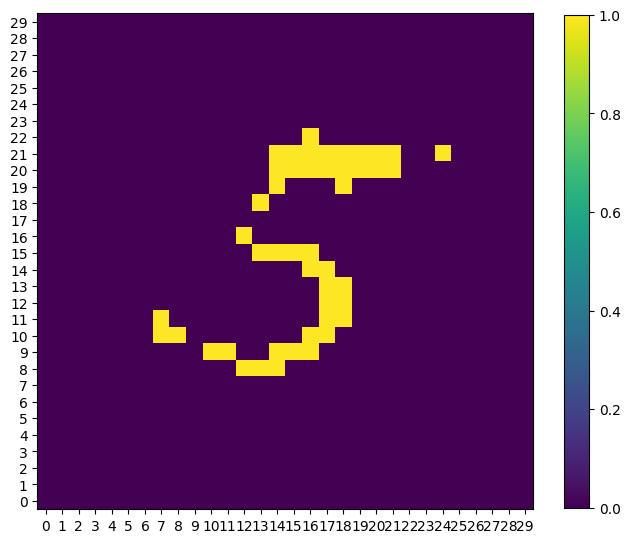

In [18]:
ys = RNG.multivariate_normal(
    mean=μ2,
    cov=Σ2,
    method=cov_mat_factor_method)
# ys = scipy.special.expit(ys)
# ys = np.where(ys > 0.5, 1, 0)
ys = np.where(ys > 2.9, 1, 0)

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
im = ax1.imshow(ys.reshape(samples_count, -1), origin='lower')
ax1.set_xticks(np.linspace(0, 29, 30))
ax1.set_yticks(np.linspace(0, 29, 30))
fig.colorbar(im, shrink=0.8, ax=ax1);

# Hier norm dist (toy case)

## Ordinal encoding/decoding

In [288]:
def _encode_ordinal_ohe(value, min_value, max_value):
    bits_count = (max_value - min_value + 1)
    r = np.zeros(bits_count)
    bit_no = value - min_value
    r[bit_no] = 1
    return r
    
def _encode_ordinal_tree(value, min_value, max_value, bit_repertoir, bits_count=0):
    assert len(bit_repertoir) == 2
    assert bit_repertoir[0] != bit_repertoir[1]
    
    encoding = []
    lo_thres, hi_thres, thres = min_value, max_value, (min_value + max_value) / 2

    if not bits_count:
        bits_count = int(np.ceil(np.log2(max_value - min_value + 1)))

    for _ in range(bits_count):
        if value < thres:
            encoding.append(bit_repertoir[0])
            hi_thres = thres
        else:
            encoding.append(bit_repertoir[1])
            lo_thres = thres
            
        thres = (lo_thres + hi_thres) / 2

    return encoding

def _decode_ordinal_ohe(encoding, min_value):
    # nzb = np.flatnonzero(encoding > 0)
    # # assert len(nzb) == 1
    # assert len(nzb) > 0 
    # bit_no = nzb[0]
    bit_no = np.argmax(encoding)
    return int(min_value + bit_no)

def _decode_ordinal_tree(encoding, min_value, max_value, bit_repertoir):
    assert len(bit_repertoir) == 2
    assert bit_repertoir[0] != bit_repertoir[1]
    
    assert max_value >= min_value
    value = (min_value + max_value) / 2

    for bit in encoding:
        if bit == bit_repertoir[0]:
            max_value = value
        else:
            min_value = value

        value = (min_value + max_value) / 2

    return int(np.round(value, decimals=0))

def encode_ordinal(value, min_value, max_value, method, bits_count=0):
    match method:
        case 'ohe':
            return _encode_ordinal_ohe(value, min_value, max_value)
        case 'tree': 
            return _encode_ordinal_tree(value, min_value, max_value, [0, 1], bits_count)
        case 'tree_bipolar':
            return _encode_ordinal_tree(value, min_value, max_value, [-1, +1], bits_count)
        case '_':
            assert False, f'Unkown encoding method \"{method}\"'

def decode_ordinal(encoding, min_value, max_value, method):
    assert max_value >= min_value

    match method:
        case 'ohe':
            return _decode_ordinal_ohe(encoding, min_value)
        case 'tree': 
            return _decode_ordinal_tree(encoding, min_value, max_value, [0, 1])
        case 'tree_bipolar':
            return _decode_ordinal_tree(encoding, min_value, max_value, [-1, +1])
        case '_':
            assert False, f'Unkown decoding method \"{method}\"'

In [289]:
min_value = 0
max_value = 4

print('OHE encoding. Perfect for conditioning, but requires ad-hoc to sample from Normal distr')
# Natural way to sample from Normal distr = binarize sample, e.g. np.where(sample > .5, 1, 0).
# In OHE binarization could lead to OHE violation: either 0 bits or several bits.
# The reason for OHE violation: mutual exclusivity of bits - only one bit within sample must be ON.
# Possible ad-hoc for OHE = np.argmax(sample)
# In other words. It's hardly possible to sample joint entity (np.r_[encoding, pixels]) from Multivariate normal distr without ad-hoc handling for OHE
# (idea was that it's possible to sample figures perfectly if only figure is sampled alongside with variant)

for v in range(min_value, max_value + 1):
    encoding = encode_ordinal(v, min_value, max_value, method='ohe')
    v_hat = decode_ordinal(encoding, min_value, max_value, method='ohe')
    print(f'{v} -> {encoding} -> {v_hat}')
    assert v == v_hat, (v, v_hat)

print('Tree encoding. Poor for conditioning, natural to sample from Normal distr')

for v in range(min_value, max_value + 1):
    encoding = encode_ordinal(v, min_value, max_value, method='tree')
    v_hat = decode_ordinal(encoding, min_value, max_value, method='tree')
    print(f'{v} -> {encoding} -> {v_hat}')
    assert v == v_hat, (v, v_hat)

print('Tree bipolar encoding. Poor for conditioning, natural to sample from Normal distr')

for v in range(min_value, max_value + 1):
    encoding = encode_ordinal(v, min_value, max_value, method='tree_bipolar')
    v_hat = decode_ordinal(encoding, min_value, max_value, method='tree_bipolar')
    print(f'{v} -> {encoding} -> {v_hat}')
    assert v == v_hat, (v, v_hat)

OHE encoding. Perfect for conditioning, but requires ad-hoc to sample from Normal distr
0 -> [1. 0. 0. 0. 0.] -> 0
1 -> [0. 1. 0. 0. 0.] -> 1
2 -> [0. 0. 1. 0. 0.] -> 2
3 -> [0. 0. 0. 1. 0.] -> 3
4 -> [0. 0. 0. 0. 1.] -> 4
Tree encoding. Poor for conditioning, natural to sample from Normal distr
0 -> [0, 0, 0] -> 0
1 -> [0, 1, 0] -> 1
2 -> [1, 0, 0] -> 2
3 -> [1, 1, 0] -> 3
4 -> [1, 1, 1] -> 4
Tree bipolar encoding. Poor for conditioning, natural to sample from Normal distr
0 -> [-1, -1, -1] -> 0
1 -> [-1, 1, -1] -> 1
2 -> [1, -1, -1] -> 2
3 -> [1, 1, -1] -> 3
4 -> [1, 1, 1] -> 4


## Toys arsenal

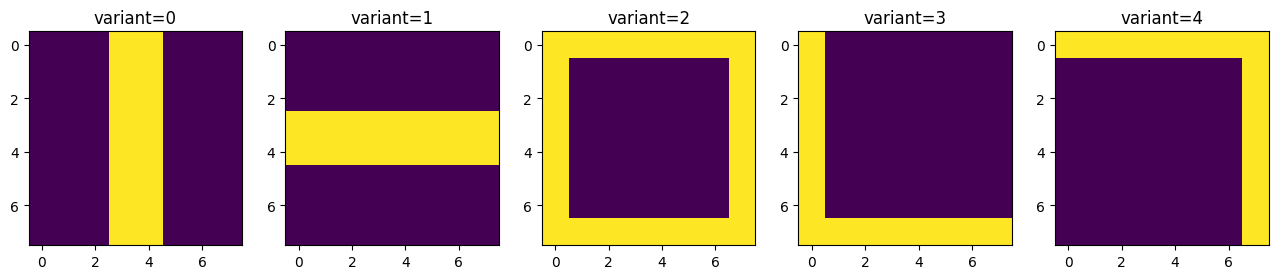

In [21]:
toys_count = 5
toys = np.zeros((toys_count,8,8))

# Thick vertical bar
toys[0][:,3] = 1
toys[0][:,4] = 1

# Thick horizontal bar
toys[1][3,:] = 1
toys[1][4,:] = 1

# Outer rect
toys[2][0,:] = 1
toys[2][-1,:] = 1
toys[2][:,0] = 1
toys[2][:,-1] = 1

# Bottom L
toys[3][:,0] = 1
toys[3][-1,:] = 1

# Top reflected L
toys[4][0,:] = 1
toys[4][:,-1] = 1

fig, axes = plt.subplots(1, toys.shape[0])
fig.set_figwidth(16)

assert len(axes) == toys.shape[0]

for i, ax in zip(range(toys.shape[0]), axes):
    ax.set_title(f'variant={i}')
    ax.imshow(toys[i]);    

## Sample toy without conditioning

### 0) No var. encoding

In [22]:
toy_dataset0 = []
variants = RNG.choice(np.arange(5), size=1000)

for variant in variants:
    image = toys[variant]
    toy_dataset0.append(image.ravel())

toy_dataset0 = np.array(toy_dataset0)

In [23]:
toy_dataset_scaler0 = StandardScaler()
toy_dataset_norm0 = toy_dataset_scaler0.fit_transform(toy_dataset0)
cov_mat0 = np.cov(toy_dataset_norm0, rowvar=False)
assert cov_mat0.shape == (64, 64)
cov_mat0 += np.eye(len(cov_mat0)) * 0.000001

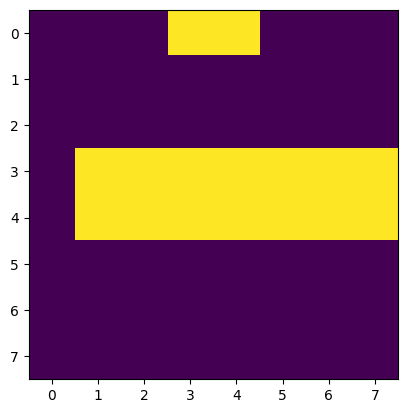

In [24]:
# chol0 = np.linalg.cholesky(cov_mat0)
sample = RNG.multivariate_normal(mean=np.zeros(len(cov_mat0)), cov=cov_mat0)
sample = toy_dataset_scaler0.inverse_transform(sample[np.newaxis,:])[0]
sample = np.where(sample > .5, 1, 0)

plt.imshow(vec_to_square_matrix(sample));

Видно, что фигура (toy) сэмплится не радомно. Можно усмотреть ту или иную фигуру. Но при этом часто бывают артефакты. 

### 1) OHE var. encoding

In [25]:
toy_dataset1 = []
variants = RNG.choice(np.arange(5), size=1000)

for variant in variants:
    image = toys[variant]
    variant_enc = encode_ordinal(variant, 0, toys_count-1, method='ohe')
    enc_len1 = len(variant_enc)
    toy_dataset1.append(np.r_[variant_enc, image.ravel()])

assert enc_len1 == toys_count
toy_dataset1 = np.array(toy_dataset1)

In [26]:
toy_dataset_scaler1 = StandardScaler()
toy_dataset_norm1 = toy_dataset_scaler1.fit_transform(toy_dataset1)
cov_mat1 = np.cov(toy_dataset_norm1, rowvar=False)
assert cov_mat1.shape == (enc_len1 + 64, enc_len1 + 64)

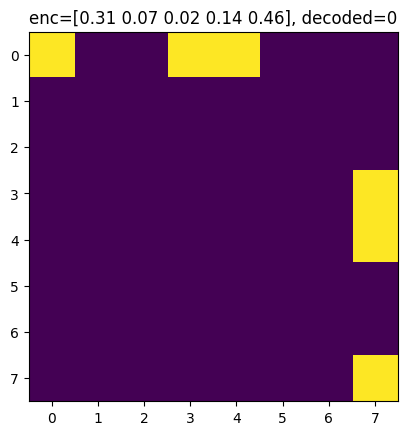

In [27]:
sample = RNG.multivariate_normal(mean=np.zeros(len(cov_mat1)), cov=cov_mat1)
sample = toy_dataset_scaler1.inverse_transform(sample[np.newaxis,:])[0]
variant_enc = sample[:enc_len1]
pixels = sample[enc_len1:]
pixels = np.where(pixels > .5, 1, 0)

plt.imshow(vec_to_square_matrix(pixels));
decoded = decode_ordinal(variant_enc, 0, toys_count-1, method='ohe') # may be very inaccurate
plt.title(f'enc={np.round(variant_enc, 2)}, decoded={decoded}');

Видно, что добавление кодировки в матрицу ковариации не помогает. Фигура (toy) сэмплится пусть и не радомно, но всё равно с ошибками.  
Причина, в том, что вариант кодировки тоже сэмплится с элементом рандомности и поэтому не может влиять сильно на выбор той или иной конфигурации фигуры

### 2) Tree[-1,+1] var. encoding

In [28]:
toy_dataset2 = []
variants = RNG.choice(np.arange(5), size=1000)

for variant in variants:
    image = toys[variant]
    variant_enc = encode_ordinal(variant, 0, toys_count-1, method='tree_bipolar', bits_count=3)
    enc_len2 = len(variant_enc)
    toy_dataset2.append(np.r_[variant_enc, image.ravel()])

assert enc_len2 == 3
toy_dataset2 = np.array(toy_dataset2)

In [29]:
toy_dataset_scaler2 = StandardScaler()
toy_dataset_norm2 = toy_dataset_scaler2.fit_transform(toy_dataset2)
cov_mat2 = np.cov(toy_dataset_norm2, rowvar=False)
assert cov_mat2.shape == (enc_len2+64, enc_len2+64)

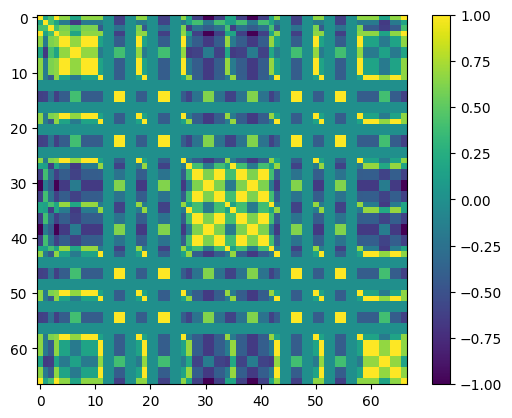

In [30]:
plt.imshow(cov_mat2);
plt.colorbar();

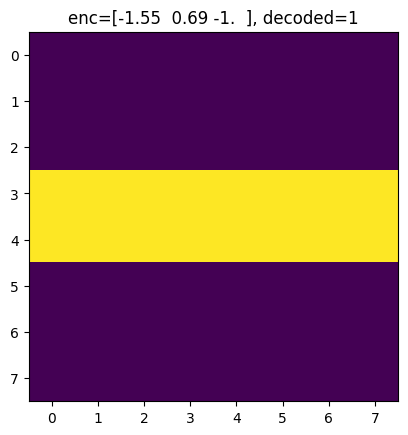

In [31]:
sample = RNG.multivariate_normal(mean=np.zeros(len(cov_mat2)), cov=cov_mat2)
sample = toy_dataset_scaler2.inverse_transform(sample[np.newaxis,:])[0]
variant_enc = sample[:enc_len2]
pixels = sample[enc_len2:]
pixels = np.where(pixels > .5, 1, 0)

plt.imshow(vec_to_square_matrix(pixels));
decoded = decode_ordinal(np.sign(variant_enc), 0, toys_count-1, method='tree_bipolar') # may be very inaccurate
plt.title(f'enc={np.round(variant_enc, 2)}, decoded={decoded}');

Видно, что добавление Tree кодировки в матрицу ковариации тоже не помогает. Фигура (toy) сэмплится пусть и не радомно, но всё равно с ошибками.  
Причина, в том, что:  
а) вариант кодировки тоже сэмплится с элементом рандомности и поэтому не может влиять сильно на выбор той или иной конфигурации фигуры.  
б) ни один из битов в кодировке не определяет уникально ту или иную фигуру. 

### 3) Tree[0,1] var. encoding

In [32]:
toy_dataset3 = []
variants = RNG.choice(np.arange(5), size=1000)

for variant in variants:
    image = toys[variant]
    variant_enc = encode_ordinal(variant, 0, toys_count-1, method='tree', bits_count=3)
    enc_len3 = len(variant_enc)
    toy_dataset3.append(np.r_[variant_enc, image.ravel()])

assert enc_len3 == 3
toy_dataset3 = np.array(toy_dataset3)

In [33]:
toy_dataset_scaler3 = StandardScaler()
toy_dataset_norm3 = toy_dataset_scaler3.fit_transform(toy_dataset3)
cov_mat3 = np.cov(toy_dataset_norm3, rowvar=False)
assert cov_mat3.shape == (enc_len3+64, enc_len3+64)

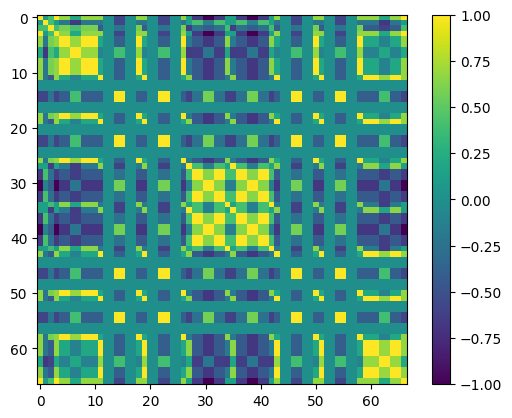

In [34]:
plt.imshow(cov_mat3);
plt.colorbar();

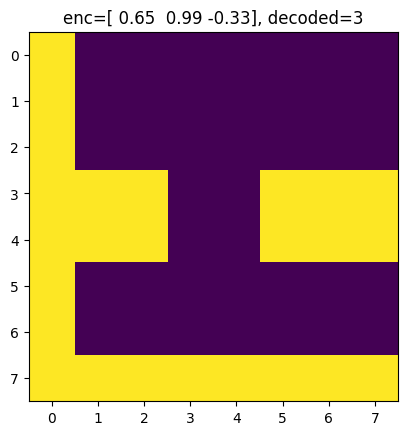

In [35]:
sample = RNG.multivariate_normal(mean=np.zeros(len(cov_mat3)), cov=cov_mat3)
sample = toy_dataset_scaler3.inverse_transform(sample[np.newaxis,:])[0]
variant_enc = sample[:enc_len3]
pixels = sample[enc_len3:]
pixels = np.where(pixels > .5, 1, 0)

plt.imshow(vec_to_square_matrix(pixels));
decoded = decode_ordinal(np.where(variant_enc > 0.5, 1, 0), 0, toys_count-1, method='tree') # may be very inaccurate
plt.title(f'enc={np.round(variant_enc, 2)}, decoded={decoded}');

Картина аналогичная Tree-bipolar кодировке

## Sample toy with conditioning

### rearrange_cov_mat_for_conditioning

In [410]:
def exchange_cov_mat_vars(cov_mat, ind_a, ind_b):
    row_a = cov_mat[ind_a].copy()
    cov_mat[ind_a] = cov_mat[ind_b]
    cov_mat[ind_b] = row_a
    col_a = cov_mat[:,ind_a].copy()
    cov_mat[:,ind_a] = cov_mat[:,ind_b]
    cov_mat[:,ind_b] = col_a

def rearrange_cov_mat_for_conditioning(cov_mat, condition_inds):
    assert len(condition_inds) <= len(cov_mat)
    cov_mat_new = cov_mat.copy()
    assert cov_mat_new.base is None
    ind_mapping = np.arange(len(cov_mat))
    processed_inds = set()
        
    for serial, ind in enumerate(condition_inds):
        assert not ind in processed_inds, ind
        processed_inds.add(ind)
        exchange_cov_mat_vars(cov_mat_new, serial, ind)
        x = ind_mapping[serial]
        ind_mapping[serial] = ind_mapping[ind]
        ind_mapping[ind] = x

    assert set(ind_mapping) == set(range(len(cov_mat)))
    return cov_mat_new, ind_mapping

In [412]:
cov_mat_test = np.array([
    [11, 12, 13], 
    [21, 22, 23], 
    [31, 32, 33], 
])
cov_mat, ind_mapping = rearrange_cov_mat_for_conditioning(cov_mat_test, [])
assert np.all(cov_mat == np.array([
    [11, 12, 13], 
    [21, 22, 23], 
    [31, 32, 33], 
]))
assert np.all(ind_mapping == [0, 1, 2])

cov_mat_test = np.array([
    [11, 12, 13], 
    [21, 22, 23], 
    [31, 32, 33], 
])
cov_mat, ind_mapping = rearrange_cov_mat_for_conditioning(cov_mat_test, [1])
assert np.all(cov_mat == np.array([
    [22, 21, 23], 
    [12, 11, 13], 
    [32, 31, 33], 
]))
assert np.all(ind_mapping == [1, 0, 2])

cov_mat_test = np.array([
    [11, 12, 13, 14, 15], 
    [21, 22, 23, 24, 25], 
    [31, 32, 33, 34, 35], 
    [41, 42, 43, 44, 45], 
    [51, 52, 53, 54, 55], 
])
cov_mat, ind_mapping = rearrange_cov_mat_for_conditioning(cov_mat_test, [1, 3])
assert np.all(cov_mat == np.array([
    [22, 24, 23, 21, 25], 
    [42, 44, 43, 41, 45], 
    [32, 34, 33, 31, 35], 
    [12, 14, 13, 11, 15], 
    [52, 54, 53, 51, 55],
]))
assert np.all(ind_mapping == [1, 3, 2, 0, 4])

### get_conditioned_mvn

In [395]:
def get_conditioned_mvn(conditioned_var_inds, conditioned_var_vals, cov_mat):
    assert len(conditioned_var_inds) == len(conditioned_var_vals)
    l = len(conditioned_var_inds)

    # rearrangement moves condt. vals to upper left corner of cov_mat, ind mapping is returned so it it's easy to remap back
    Σ, ind_mapping = rearrange_cov_mat_for_conditioning(cov_mat, conditioned_var_inds) 
    Σ11 = Σ[:l,:l]
    Σ11 += np.eye(len(Σ11)) * 0.0000001 # tikhonov regularization to avoid singular matrix
    Σ12 = Σ[:l,l:]
    solved = sp.linalg.solve(Σ11, Σ12, assume_a='pos').T
    μ2 = solved @ conditioned_var_vals
    Σ22 = Σ[l:,l:]
    Σ2 = Σ22 - (solved @ Σ12)

    return μ2, Σ2, ind_mapping

### sample_mvn_with_conditioning

In [401]:
def sample_mvn_with_conditioning(conditioned_var_inds, conditioned_var_vals, cov_mat):
    μ2, Σ2, ind_mapping = get_conditioned_mvn(conditioned_var_inds, conditioned_var_vals, cov_mat)

    # Sample and remap back values to original vector structure
    sample_raw = RNG.multivariate_normal(mean=μ2, cov=Σ2)
    sample_raw = np.r_[conditioned_var_vals, sample_raw]
    sample = np.zeros(len(sample_raw))
    sample[ind_mapping] = sample_raw[np.arange(len(sample_raw))]
    
    return sample

### sample_toy_with_conditioning

In [402]:
def sample_toy_with_conditioning(variant_enc, cov_mat, scaler):
    enc_len = len(variant_enc)
    
    given_data = np.r_[variant_enc, np.zeros(64)]
    given_data = scaler.transform(given_data[np.newaxis,:])[0]
    given_data = given_data[:enc_len]

    sample = sample_mvn_with_conditioning(np.arange(enc_len), given_data, cov_mat)
    
    sample = scaler.inverse_transform(sample[np.newaxis,:])[0]
    variant_enc = sample[:enc_len]
    pixels = sample[enc_len:]
    pixels = np.where(pixels > .5, 1, 0)
    
    return variant_enc, pixels

### condition_scaler

In [447]:
# dirty hack to force StandardScaler to work with conditioned vars only
def condition_scaler(scaler, condition_var_inds):
    scaler = copy.deepcopy(scaler)
    scaler.mean_ = scaler.mean_[condition_var_inds]
    scaler.scale_ = scaler.scale_[condition_var_inds]
    scaler.var_ = scaler.var_[condition_var_inds]
    scaler.n_features_in_ = len(condition_var_inds)
    return scaler

In [451]:
test_dataset = RNG.choice([0,1], (100, 5))
scaler = StandardScaler()
scaler.fit(test_dataset)
x = scaler.transform(test_dataset)
x_back = scaler.inverse_transform(x)

inds = [0, 2]
test_dataset_hat = test_dataset[:,inds]
scaler_hat = condition_scaler(scaler, inds)
y = scaler_hat.transform(test_dataset_hat)
y_back = scaler_hat.inverse_transform(y)

assert np.all(x[:,inds] == y)
assert np.all(x_back[:,inds] == y_back)

### 4) OHE var. encoding

In [303]:
toy_dataset4 = []
variants = RNG.choice(np.arange(5), size=1000)

for variant in variants:
    image = toys[variant]
    variant_enc = encode_ordinal(variant, 0, toys_count-1, method='ohe')
    enc_len4 = len(variant_enc)
    toy_dataset4.append(np.r_[variant_enc, image.ravel()])

assert enc_len4 == toys_count
toy_dataset4 = np.array(toy_dataset4)

In [304]:
toy_dataset_scaler4 = StandardScaler()
toy_dataset_norm4 = toy_dataset_scaler4.fit_transform(toy_dataset4)
cov_mat4 = np.cov(toy_dataset_norm4, rowvar=False)
assert cov_mat4.shape == (enc_len4+64, enc_len4+64)

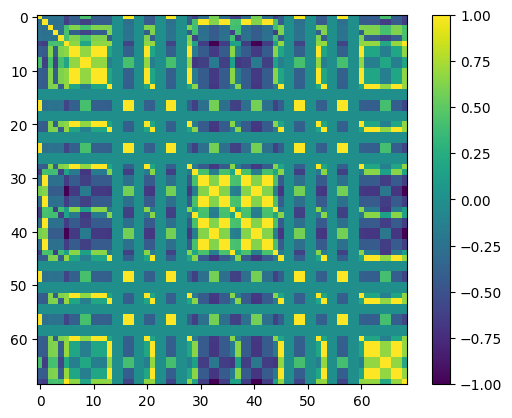

In [305]:
plt.imshow(cov_mat4);
plt.colorbar();

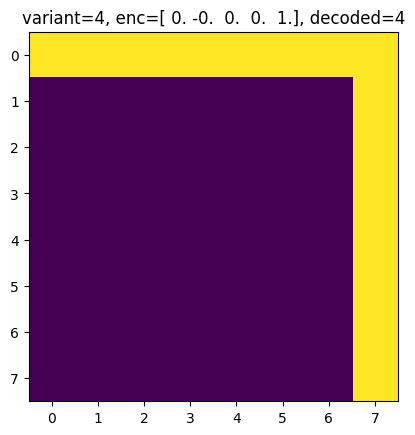

In [314]:
variant = 4
variant_enc = encode_ordinal(variant, 0, toys_count-1, method='ohe') # topdown conditioning (variant -> pixels)
variant_enc, pixels = sample_toy_with_conditioning(variant_enc, cov_mat4, toy_dataset_scaler4)

plt.imshow(vec_to_square_matrix(pixels));
plt.title(f'variant={variant}, enc={np.round(variant_enc, 2)}, decoded={decode_ordinal(variant_enc, 0, toys_count-1, method='ohe')}');

С OHE-кодировкой и кондишнингом фигура сэмплится корректно.  

### 4.1) Multi-OHE var. encoding

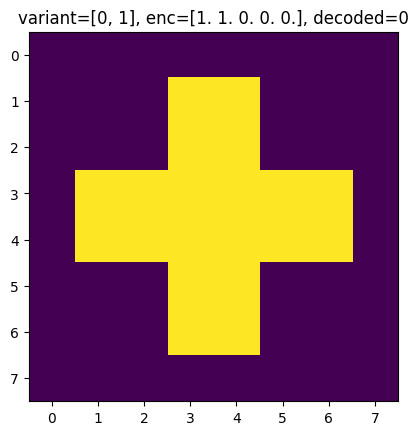

In [387]:
multi_variant = [0, 1]
multi_variant_enc = np.zeros(toys_count)

for variant in multi_variant:
    variant_enc = encode_ordinal(variant, 0, toys_count-1, method='ohe') # topdown conditioning (variant -> pixels)
    multi_variant_enc += variant_enc

assert np.all(np.isin(multi_variant_enc, [0, 1]))
    
variant_enc, pixels = sample_toy_with_conditioning(multi_variant_enc, cov_mat4, toy_dataset_scaler4)

plt.imshow(vec_to_square_matrix(pixels));
plt.title(f'variant={multi_variant}, enc={np.round(variant_enc, 2)}, decoded={decode_ordinal(variant_enc, 0, toys_count-1, method='ohe')}');

Видно, что настоящего чуда не произошло, но и совсем провала тоже. Мульт фигуры сэмплятся, пусть и с искажениями. Всё таки и система не видела их совместно никогда...

### 5) Tree[0,1] var. encoding

In [315]:
toy_dataset5 = []
variants = RNG.choice(np.arange(5), size=1000)

for variant in variants:
    image = toys[variant]
    variant_enc = encode_ordinal(variant, 0, toys_count-1, method='tree')
    enc_len5 = len(variant_enc)
    toy_dataset5.append(np.r_[variant_enc, image.ravel()])

assert enc_len5 == 3
toy_dataset5 = np.array(toy_dataset5)

In [316]:
toy_dataset_scaler5 = StandardScaler()
toy_dataset_norm5 = toy_dataset_scaler5.fit_transform(toy_dataset5)
cov_mat5 = np.cov(toy_dataset_norm5, rowvar=False)
assert cov_mat5.shape == (enc_len5+64, enc_len5+64)

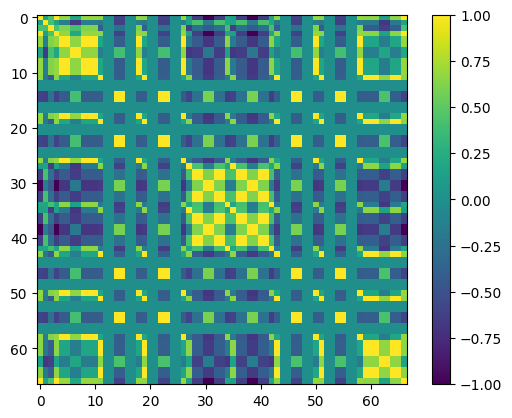

In [317]:
plt.imshow(cov_mat5);
plt.colorbar();

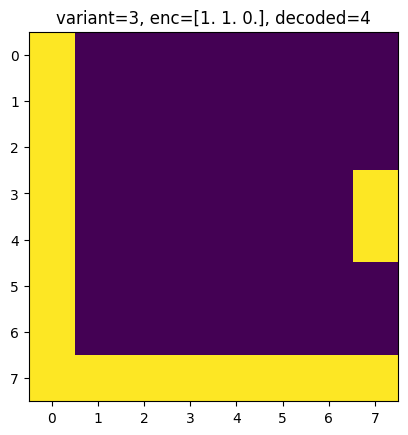

In [322]:
variant = 3
variant_enc = encode_ordinal(variant, 0, toys_count-1, method='tree') # topdown conditioning (variant -> pixels)
variant_enc, pixels = sample_toy_with_conditioning(variant_enc, cov_mat5, toy_dataset_scaler5)

plt.imshow(vec_to_square_matrix(pixels));
plt.title(f'variant={variant}, enc={np.round(variant_enc, 2)}, decoded={decode_ordinal(variant_enc, 0, toys_count-1, method='tree')}');

С Tree-кодировкой и кондишнингом фигура сэпмлится, но не всегда чисто.  
Вывод: нужен уникальный бит, чтобы ковариационная матрица могла "зацепиться" за этот факт. В OHE-кодировке такие (уникальные) биты есть, в Tree кодирвке - нет (один и тот же бит может использоваться в разных кодах)

### 6) OHE+Tree[0,1] var. encoding

In [323]:
toy_dataset6 = []
variants = RNG.choice(np.arange(5), size=1000)

for variant in variants:
    image = toys[variant]
    variant_enc_tree = encode_ordinal(variant, 0, toys_count-1, method='tree') 
    variant_enc_ohe = encode_ordinal(variant, 0, toys_count-1, method='ohe')
    variant_enc = np.r_[variant_enc_tree, variant_enc_ohe]
    enc_len6 = len(variant_enc)
    toy_dataset6.append(np.r_[variant_enc, image.ravel()])

toy_dataset6 = np.array(toy_dataset6)
assert toy_dataset6.shape[1] == 64 + enc_len6

In [324]:
toy_dataset_scaler6 = StandardScaler()
toy_dataset_norm6 = toy_dataset_scaler6.fit_transform(toy_dataset6)
cov_mat6 = np.cov(toy_dataset_norm6, rowvar=False)
assert cov_mat6.shape == (64+enc_len6, 64+enc_len6)

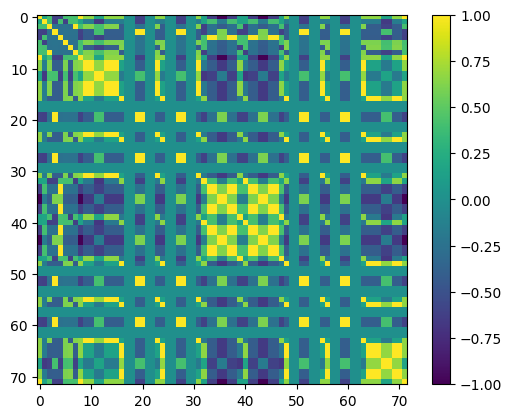

In [325]:
plt.imshow(cov_mat6);
plt.colorbar();

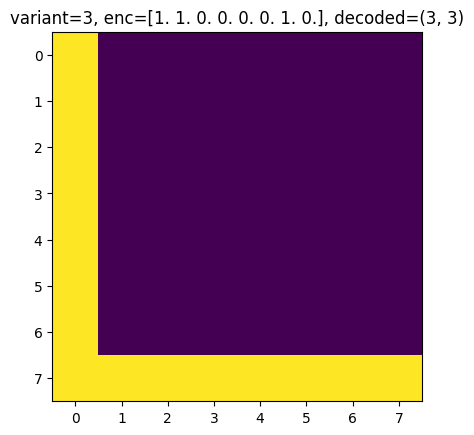

In [329]:
variant = 3
# topdown conditioning (variant -> pixels)
variant_enc_tree = encode_ordinal(variant, 0, toys_count-1, method='tree')
variant_enc_ohe = encode_ordinal(variant, 0, toys_count-1, method='ohe') 
variant_enc = np.r_[variant_enc_tree, variant_enc_ohe]
variant_enc, pixels = sample_toy_with_conditioning(variant_enc, cov_mat6, toy_dataset_scaler6)

plt.imshow(vec_to_square_matrix(pixels));
decoded_tree = decode_ordinal(variant_enc[:3], 0, toys_count-1, method='tree')
decoded_ohe = decode_ordinal(variant_enc[3:], 0, toys_count-1, method='ohe')
plt.title(f'variant={variant}, enc={np.round(variant_enc, 2)}, decoded={decoded_tree, decoded_ohe}');

Со смешанной кодировкой (Tree + OHE) и кондишнингом фигура сэмплится чисто.  
Вывод: нужен уникальный бит, чтобы ковариационная матрица могла "зацепиться" за этот факт. При этом неважно, что другие биты в кодировке могут быть "мусорными"

### 7) Augumented random code vector var. encoding

In [49]:
random_code_vec_length = 20
random_code_vectors = RNG.choice((0,1), (toys_count, random_code_vec_length))
variant_codes7 = []

# Augument each random code vector with code features
# Code feature = some combination of given number of bits
for variant_code in random_code_vectors:
    for bits_combi_len in [2]:
        code_feature = np.zeros(math.comb(len(variant_code), bits_combi_len))
        
        for code_feature_ind, bits_combi in enumerate(itertools.combinations(variant_code, bits_combi_len)):
            code_feature[code_feature_ind] = np.all(bits_combi)
            
        variant_code = np.r_[variant_code, code_feature]            

    variant_codes7.append(variant_code)

variant_codes7 = np.array(variant_codes7)
variant_codes7.shape

(5, 210)

In [50]:
# Verify if every variant_code has at least one unique code feature (unique bits combination) in an augumented part
# Several launches might be required to pass through this cell
uncovered_variant_codes = set(range(toys_count))
variant_code_to_unique_bits_count = defaultdict(int)
augumented = variant_codes7[:,random_code_vec_length:]

for code_feature_ind in np.flatnonzero(augumented.sum(axis=0) == 1):
    code_feature_ind_belongs_to = np.flatnonzero(augumented[:,code_feature_ind])
    assert len(code_feature_ind_belongs_to) == 1
    code_feature_ind_belongs_to = code_feature_ind_belongs_to[0]
    assert code_feature_ind_belongs_to >= 0 and code_feature_ind_belongs_to < toys_count
    # print(f'code_feature #{code_feature_ind} belongs to {code_feature_ind_belongs_to}')
    uncovered_variant_codes.discard(code_feature_ind_belongs_to)
    variant_code_to_unique_bits_count[int(code_feature_ind_belongs_to)] += 1

assert len(uncovered_variant_codes) == 0, uncovered_variant_codes
pd.DataFrame(variant_code_to_unique_bits_count, index=['Unique bits count'])

,3,2,0,4,1
Unique bits count,46,12,20,16,10


Получили систему кодировки, когда для каждого кода варианта есть уникальные биты.  
В ситуации, когда размерность random_code_vec_length невелика (10-20), возможно потребуется несколько запусков

In [330]:
toy_dataset7 = []
variants = RNG.choice(np.arange(5), size=1000)

for variant in variants:
    image = toys[variant]
    variant_enc = variant_codes7[variant]
    enc_len7 = len(variant_enc)
    toy_dataset7.append(np.r_[variant_enc, image.ravel()])

toy_dataset7 = np.array(toy_dataset7)
assert toy_dataset7.shape[1] == 64 + enc_len7

In [331]:
toy_dataset_scaler7 = StandardScaler()
toy_dataset_norm7 = toy_dataset_scaler7.fit_transform(toy_dataset7)
cov_mat7 = np.cov(toy_dataset_norm7, rowvar=False)
assert cov_mat7.shape == (64+enc_len7, 64+enc_len7)

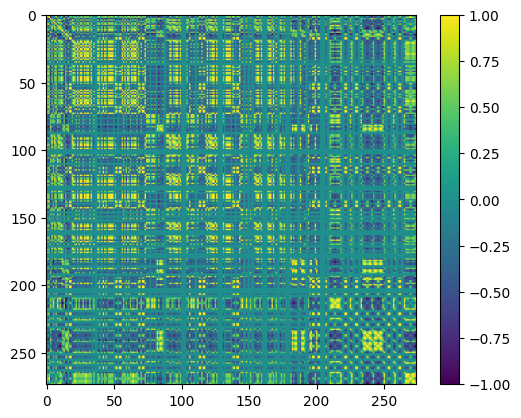

In [332]:
plt.imshow(cov_mat7);
plt.colorbar();

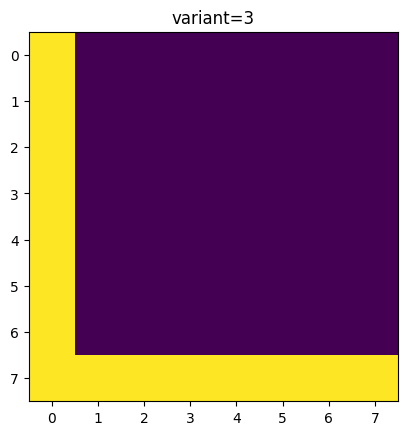

In [336]:
variant = 3
# topdown conditioning (variant -> pixels)
variant_enc = variant_codes7[variant]
variant_enc, pixels = sample_toy_with_conditioning(variant_enc, cov_mat7, toy_dataset_scaler7)

plt.imshow(vec_to_square_matrix(pixels));
plt.title(f'variant={variant}');

Как и ожидалось, при наличии уникальных бит в кодировке и кондишнингом, фигура сэмплится чисто.  
Вывод: нужен уникальный бит, чтобы ковариационная матрица могла "зацепиться" за этот факт. При этом неважно, что другие биты в кодировке могут быть "мусорными"

## Sample variant with conditioning

### toy_dataset8 & cov_mat8

In [398]:
toy_dataset8 = []
variants = RNG.choice(np.arange(5), size=1000)

for variant in variants:
    image = toys[variant]
    variant_enc = encode_ordinal(variant, 0, toys_count-1, method='ohe')
    enc_len8 = len(variant_enc)
    toy_dataset8.append(np.r_[variant_enc, image.ravel()])

toy_dataset8 = np.array(toy_dataset8)

In [932]:
toy_dataset_scaler8 = StandardScaler()
toy_dataset_norm8 = toy_dataset_scaler8.fit_transform(toy_dataset8)
cov_mat8 = np.cov(toy_dataset_norm8, rowvar=False)
cov_mat8.flags.writeable = False

### variant_enc_scaler

In [794]:
variant_enc_scaler = condition_scaler(toy_dataset_scaler8, np.arange(enc_len8))

### variant_encoding_mvn

In [966]:
Σ = cov_mat8[:enc_len8,:enc_len8].copy()
assert Σ.base is None
Σ += np.eye(len(Σ)) * 0.0000001 # tikhonov regularization to avoid singular matrix
variant_encoding_mvn = sp.stats.multivariate_normal(cov=Σ)
# mean2, Σ2 = sp.stats.multivariate_normal.fit(toy_dataset_norm8[:,:5]) <- дает такой же результат, что и пред. строка

x_list = variant_enc_scaler.transform(
    np.r_[
        np.eye(5),
        [
            [1, 1, 0, 0, 0],
            [.8, 0, 0, .7, 0],
            [0.15, -0.15, -0.26, 1.00, 0.26],
            [0.2, -0.2, 0.57, 0.08, 0.35],
            [0.19, -0.19, 0.551, 0.09, 0.36],
        ],
    ]
)
x_list = np.r_[x_list, [[1, 0, 0, 0, 0]]] # this must trigger low lkhd value because value is not transformed by scaler (unexpected high values!)

for i, (x, lkhd) in enumerate(zip(x_list, variant_encoding_mvn.logpdf(x_list))):
    print(f'{i:2}) {str(np.round(variant_enc_scaler.inverse_transform([x]), 2)[0]):35}: {lkhd:.2f}')

 0) [ 1.  0. -0.  0.  0.]              : 0.93
 1) [ 0.  1. -0.  0.  0.]              : 0.97
 2) [0. 0. 1. 0. 0.]                   : 1.08
 3) [ 0.  0. -0.  1.  0.]              : 1.07
 4) [ 0.  0. -0.  0.  1.]              : 1.04
 5) [ 1.  1. -0.  0.  0.]              : -6250859.38
 6) [ 0.8  0.  -0.   0.7  0. ]         : -1562713.53
 7) [ 0.15 -0.15 -0.26  1.    0.26]    : 0.62
 8) [ 0.2  -0.2   0.57  0.08  0.35]    : 2.20
 9) [ 0.19 -0.19  0.55  0.09  0.36]    : -4.00
10) [0.59 0.2  0.2  0.2  0.2 ]         : -973574.89


1) Хорошо. MVN позволяет отделить зёрна от плевел. Явно неправдоподобные варианты (типа 5,6 или 10) кодировки получают экстремально низкую оценку lkhd. 
2) Плохо. Вариант 8 и 0. Вариант 8 - не совсем булшит, но явно менее правдоподобнее, чем 0. В 0-ом наличиствует взаимоисключение, в 8-ом видна смесь. Но при этом lkhd 8 выше 0.  

**Вывод**: lkhd можно использовать для отсева булшита, но для точного сравнения - сомнительно.

### Noising

In [55]:
def add_noise_to_bv(bv, percentage, method):
    assert percentage >= 0 and percentage <= 1, percentage
    bv = bv.copy()
    
    match method:
        case 'flip':
            inds = RNG.choice(len(bv), int(len(bv) * percentage), replace=False)

            if len(inds) > 0:
                bv[inds] = (bv[inds] + 1) % 2
        case 'add':
            zero_bit_inds = np.flatnonzero(bv == 0)
            inds = RNG.choice(zero_bit_inds, int(len(zero_bit_inds) * percentage), replace=False)

            if len(inds) > 0:
                bv[inds] = 1
        case 'drop':
            nonzero_bit_inds = np.flatnonzero(bv != 0)
            inds = RNG.choice(nonzero_bit_inds, int(len(nonzero_bit_inds) * percentage), replace=False)

            if len(inds) > 0:
                bv[inds] = 0
        case _:
            assert False, f'Unknown noising method \"{method}\"'

    assert bv.base is None
    return bv

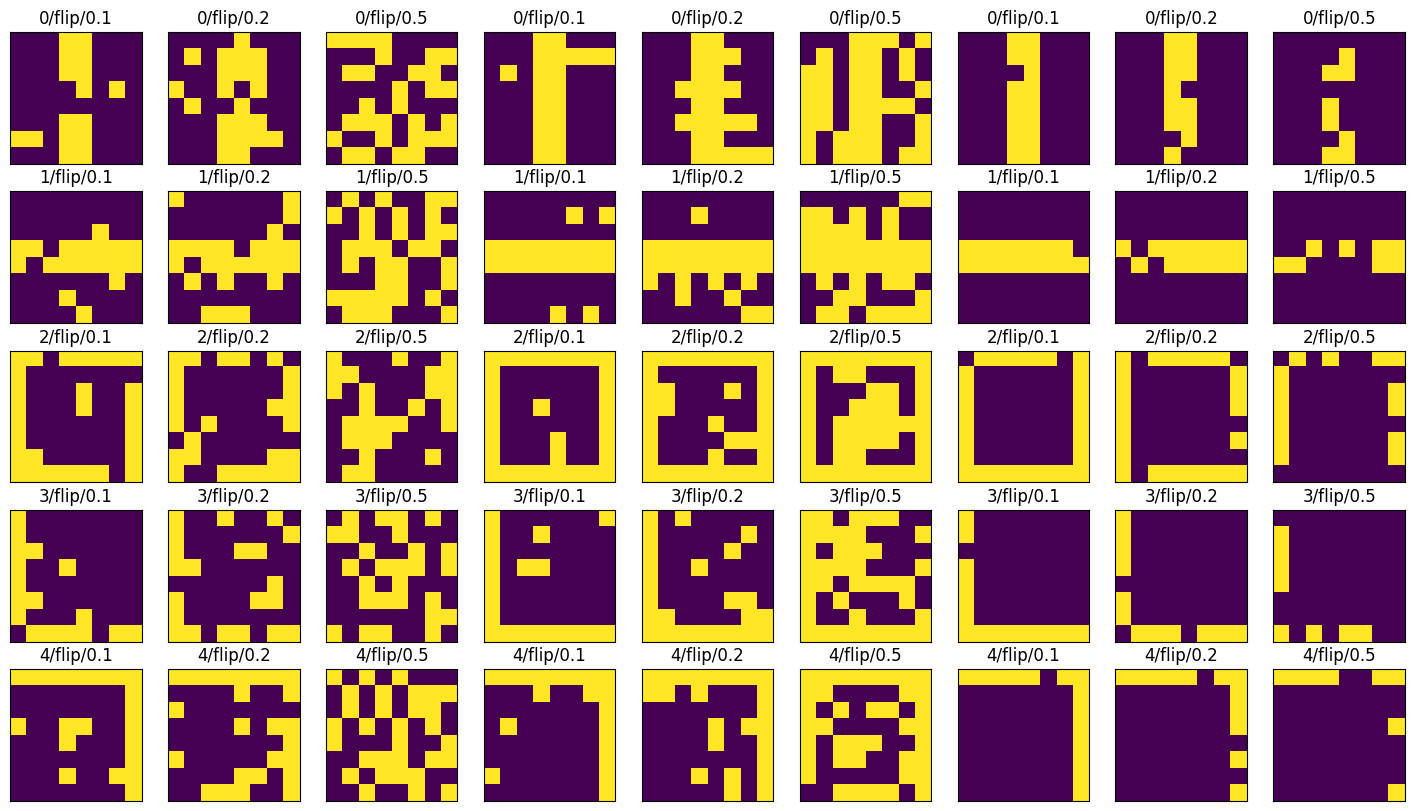

In [56]:
fig, axes = plt.subplots(len(toys), 9)
fig.set_figwidth(18)
fig.set_figheight(len(toys) * 2)

for variant, (toy, toy_axes) in enumerate(zip(toys, axes)):
    toy_axes_ind = 0
    
    for method in ['flip', 'add', 'drop']:
        for p in [0.1, 0.2, 0.5]:
            bv = add_noise_to_bv(toy.ravel(), p, method=method)
            ax = toy_axes[toy_axes_ind]
            ax.imshow(vec_to_square_matrix(bv))
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f'{variant}/flip/{p:.1f}')
            toy_axes_ind += 1

### 8.1) Cond on noisy, sample whole

![](./img/sample-variant-8-01.jpg)

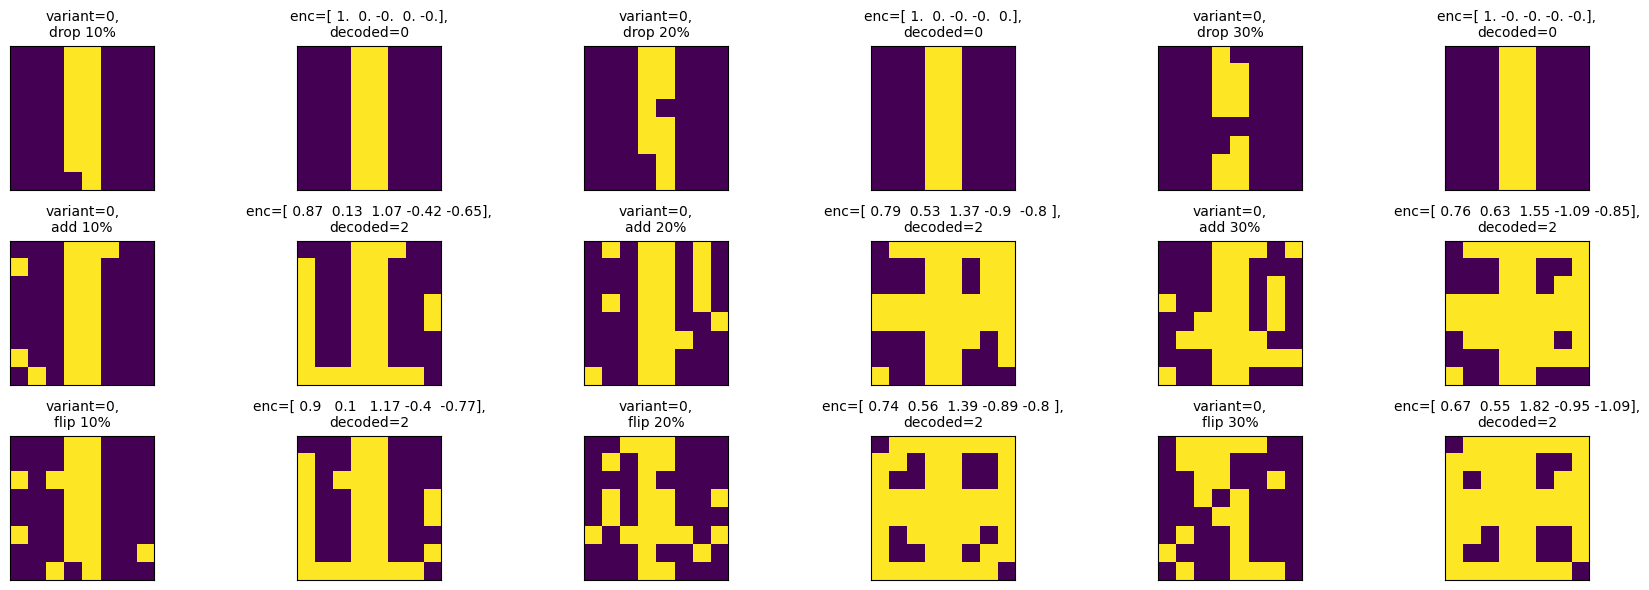

In [561]:
variant = 0
toy_bv = toys[variant].ravel()

method_list = ['drop', 'add', 'flip']
noise_p_list = [0.1, 0.2, 0.3]

fig, axes = plt.subplots(len(method_list), len(noise_p_list) * 2)
fig.set_figwidth(18)
fig.set_figheight(len(method_list) * 2)

for method, method_axes in zip(method_list, axes):
    for p, (ax1, ax2) in zip(noise_p_list, itertools.batched(method_axes, 2)):
        noise_toy_bv = add_noise_to_bv(toy_bv, p, method=method)
        nzb = np.flatnonzero(noise_toy_bv)
        nzb += enc_len8 # non zero bits we would condition on
        nzb_len = len(nzb)
        
        given_data = np.r_[np.zeros(enc_len8), noise_toy_bv]
        given_data = toy_dataset_scaler8.transform(given_data[np.newaxis,:])[0]
        given_data = given_data[nzb]
        
        sample = sample_mvn_with_conditioning(nzb, given_data, cov_mat8)
        
        sample = toy_dataset_scaler8.inverse_transform(sample[np.newaxis,:])[0]
        variant_enc = sample[:enc_len8]
        pixels = sample[enc_len8:]
        pixels = np.where(pixels > .5, 1, 0)

        ax1.imshow(vec_to_square_matrix(noise_toy_bv))
        ax1.set_title(f'variant={variant},\n{method} {p*100:.0f}%', fontdict=dict(fontsize=10));
        ax1.set_xticks([])
        ax1.set_yticks([])
        
        ax2.imshow(vec_to_square_matrix(pixels));
        ax2.set_title(f'enc={np.round(variant_enc, 2)},\ndecoded={decode_ordinal(variant_enc, 0, toys_count-1, method='ohe')}', fontdict=dict(fontsize=10));
        ax2.set_xticks([])
        ax2.set_yticks([])

plt.tight_layout()

Выводы:  
1) видно, что система путает 2 и 4. Причина в том, что 4 является подмножеством 2, поэтому 2 или 4 - верно
2) чтобы починить 1) надо добавлять больше фичей (cues), по которым система сможет сориентироваться. Сейчас таких фичей нет
3) на примере "add" видно, что закондишненные артефакты сохраняются. По идее надо делать cleanup запрос, чтобы получить очищенный вариант
4) также видно (для варианта 0), что система умудрилась даже скомбинировать разные фигурки

### 8.2) Cond on noisy, sample and cleanup variant_enc

![](./img/sample-variant-8-02.jpg)

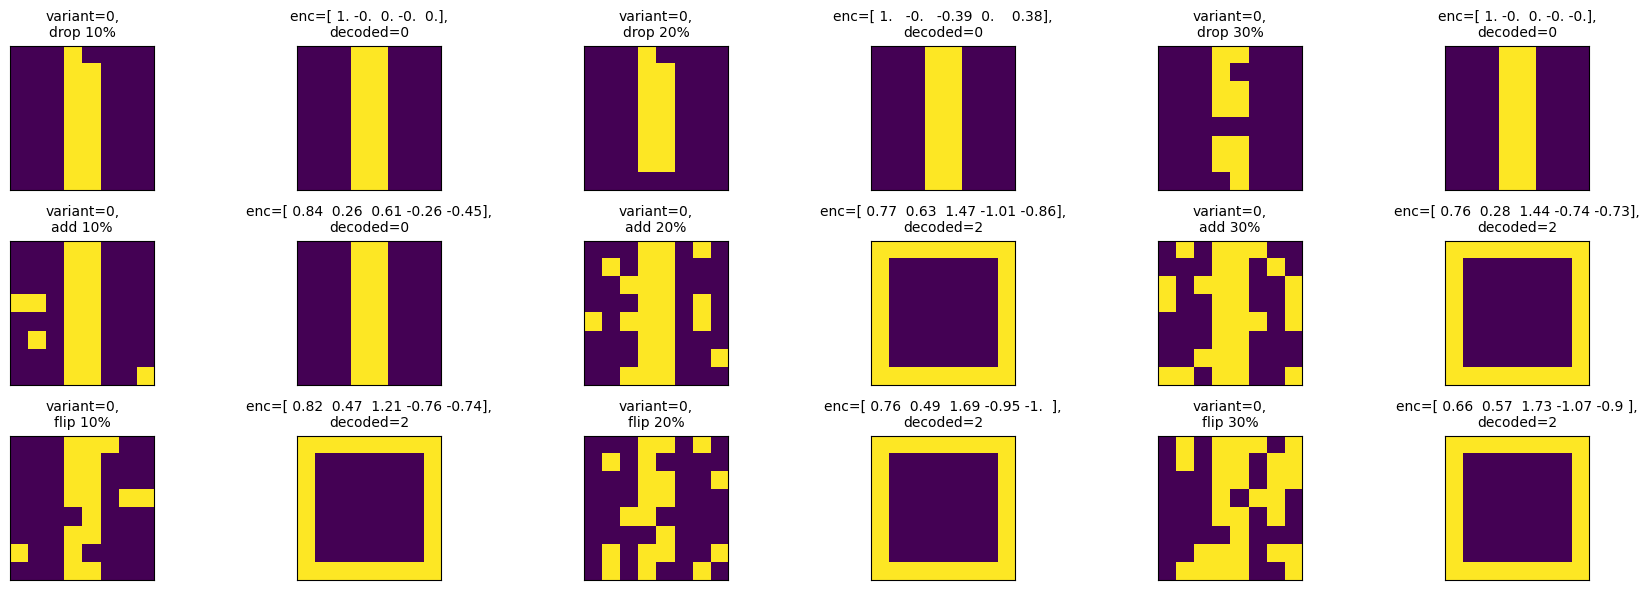

In [560]:
variant = 0
toy_bv = toys[variant].ravel()

method_list = ['drop', 'add', 'flip']
noise_p_list = [0.1, 0.2, 0.3]

fig, axes = plt.subplots(len(method_list), len(noise_p_list) * 2)
fig.set_figwidth(18)
fig.set_figheight(len(method_list) * 2)

for method, method_axes in zip(method_list, axes):
    for p, (ax1, ax2) in zip(noise_p_list, itertools.batched(method_axes, 2)):
        noise_toy_bv = add_noise_to_bv(toy_bv, p, method=method)

        # Forward pass - perceive pattern of pixels of noised toy figure and deduce variant
        nzb = np.flatnonzero(noise_toy_bv)
        nzb += enc_len8 
        nzb_len = len(nzb)

        # Condition on perceived pixels!
        given_data = np.r_[np.zeros(enc_len8), noise_toy_bv]
        given_data = toy_dataset_scaler8.transform(given_data[np.newaxis,:])[0]
        given_data = given_data[nzb]
        
        sample = sample_mvn_with_conditioning(nzb, given_data, cov_mat8)
        
        sample = toy_dataset_scaler8.inverse_transform(sample[np.newaxis,:])[0]

        # Backward pass - deduce variant and sample pixels from variant
        variant_enc = sample[:enc_len8]
        variant_decoded = decode_ordinal(variant_enc, 0, toys_count-1, method='ohe')
        
        # Condition on deduced variant!
        given_data = np.r_[encode_ordinal(variant_decoded, 0, toys_count-1, method='ohe'), np.zeros(64)]
        given_data = toy_dataset_scaler8.transform(given_data[np.newaxis,:])[0]
        given_data = given_data[:enc_len8]

        sample = sample_mvn_with_conditioning(np.arange(enc_len8), given_data, cov_mat8)
        
        sample = toy_dataset_scaler8.inverse_transform(sample[np.newaxis,:])[0]
        pixels = sample[enc_len8:]
        pixels = np.where(pixels > .5, 1, 0)

        ax1.imshow(vec_to_square_matrix(noise_toy_bv))
        ax1.set_title(f'variant={variant},\n{method} {p*100:.0f}%', fontdict=dict(fontsize=10));
        ax1.set_xticks([])
        ax1.set_yticks([])
        
        ax2.imshow(vec_to_square_matrix(pixels));
        ax2.set_title(f'enc={np.round(variant_enc, 2)},\ndecoded={variant_decoded}', fontdict=dict(fontsize=10));
        ax2.set_xticks([])
        ax2.set_yticks([])

plt.tight_layout()

### 8.3) Cond on noisy, sample variant_enc, craft variant_enc, estimate lkhd of generated toy

![](./img/sample-variant-8-03.jpg)

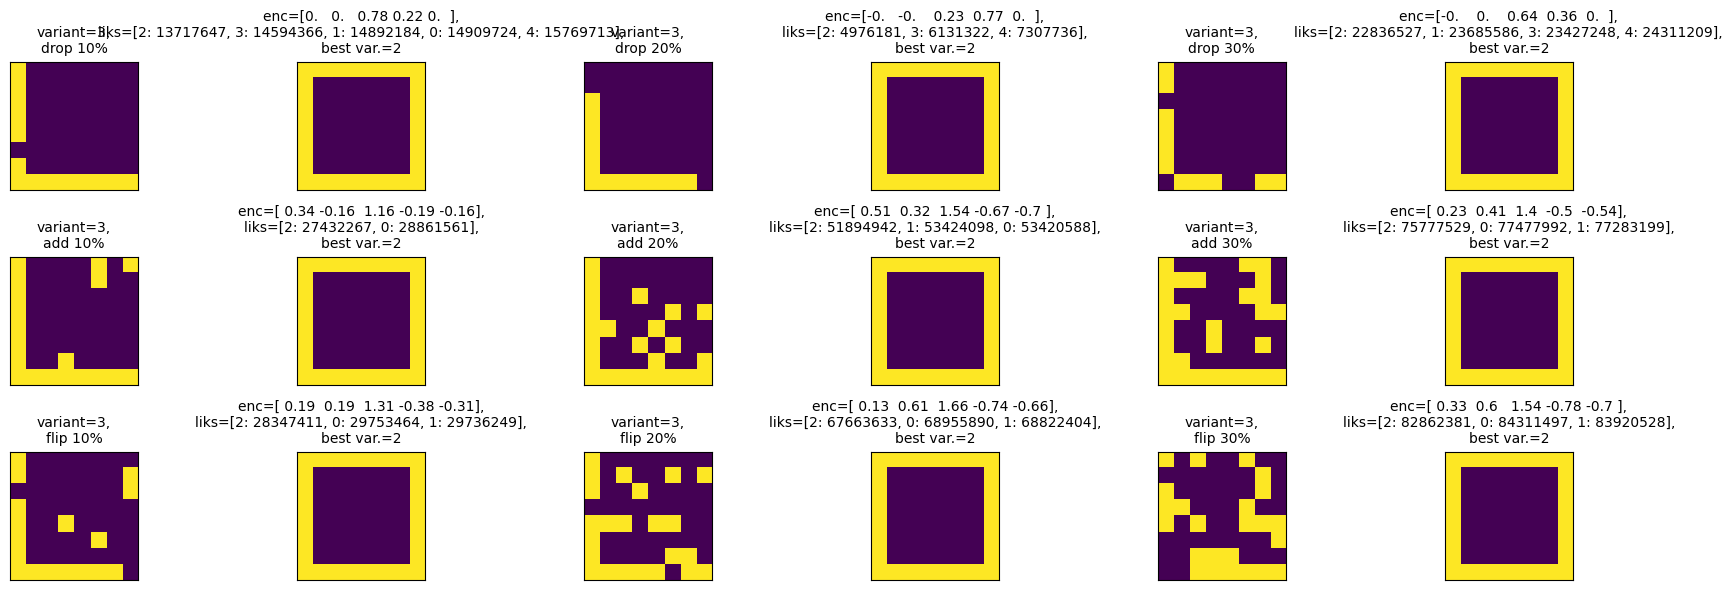

In [559]:
variant = 3
toy_bv = toys[variant].ravel()

method_list = ['drop', 'add', 'flip']
noise_p_list = [0.1, 0.2, 0.3]

fig, axes = plt.subplots(len(method_list), len(noise_p_list) * 2)
fig.set_figwidth(18)
fig.set_figheight(len(method_list) * 2)

for method, method_axes in zip(method_list, axes):
    for p, (ax1, ax2) in zip(noise_p_list, itertools.batched(method_axes, 2)):
        noise_toy_bv = add_noise_to_bv(toy_bv, p, method=method)

        # Forward pass - perceive pattern of pixels of noised toy figure and deduce variant
        nzb = np.flatnonzero(noise_toy_bv)
        nzb += enc_len8 
        nzb_len = len(nzb)

        # Condition on perceived pixels!
        given_data = np.r_[np.zeros(enc_len8), noise_toy_bv]
        given_data = toy_dataset_scaler8.transform(given_data[np.newaxis,:])[0]
        given_data = given_data[nzb]
        
        sample = sample_mvn_with_conditioning(nzb, given_data, cov_mat8)
        
        sample = toy_dataset_scaler8.inverse_transform(sample[np.newaxis,:])[0]
        variant_enc = sample[:enc_len8]

        # Backward pass - deduce variants, estimate likelihood and sample pixels from most probable variant.
        # Put it another way - we are going to run hypothesis tests
        possible_variants = np.flatnonzero(variant_enc > 0.0)
        assert len(possible_variants) > 0
        lik_estimations = []

        for possible_variant in possible_variants:
            # Condition on each possbile variant!
            given_data = np.r_[encode_ordinal(possible_variant, 0, toys_count-1, method='ohe'), np.zeros(64)]
            given_data = toy_dataset_scaler8.transform(given_data[np.newaxis,:])[0]
            given_data = given_data[:enc_len8]
    
            μ, Σ, ind_mapping = get_conditioned_mvn(np.arange(enc_len8), given_data, cov_mat8)
            assert np.all(ind_mapping == np.arange(len(cov_mat8)))
            Σ += np.eye(len(Σ)) * 0.0000001 # tikhonov regularization to avoid singular matrix
            mvn = sp.stats.multivariate_normal(mean=μ, cov=Σ)
            lik_estimation = mvn.logpdf(noise_toy_bv)

            heappush(lik_estimations, (-lik_estimation, possible_variant)) # sustain ordered list of likelihood estimations

        best_lik_estimation, best_variant = lik_estimations[0]
        given_data = np.r_[encode_ordinal(best_variant, 0, toys_count-1, method='ohe'), np.zeros(64)]
        given_data = toy_dataset_scaler8.transform(given_data[np.newaxis,:])[0]
        given_data = given_data[:enc_len8]

        sample = sample_mvn_with_conditioning(np.arange(enc_len8), given_data, cov_mat8)
        
        sample = toy_dataset_scaler8.inverse_transform(sample[np.newaxis,:])[0]
        pixels = sample[enc_len8:]
        pixels = np.where(pixels > .5, 1, 0)

        ax1.imshow(vec_to_square_matrix(noise_toy_bv))
        ax1.set_title(f'variant={variant},\n{method} {p*100:.0f}%', fontdict=dict(fontsize=10));
        ax1.set_xticks([])
        ax1.set_yticks([])
        
        ax2.imshow(vec_to_square_matrix(pixels));
        lik_estimations_fmt = ', '.join(map(lambda x: f'{int(x[1])}: {x[0]:.0f}', lik_estimations))
        ax2.set_title(f'enc={np.round(variant_enc, 2)},\nliks=[{lik_estimations_fmt}],\nbest var.={best_variant}', fontdict=dict(fontsize=10));
        ax2.set_xticks([])
        ax2.set_yticks([])

plt.tight_layout()

### 8.4) Selective cond on noisy (ON), sample variant_enc, estimate lkhd of variant_enc

![](./img/sample-variant-8-04.jpg)

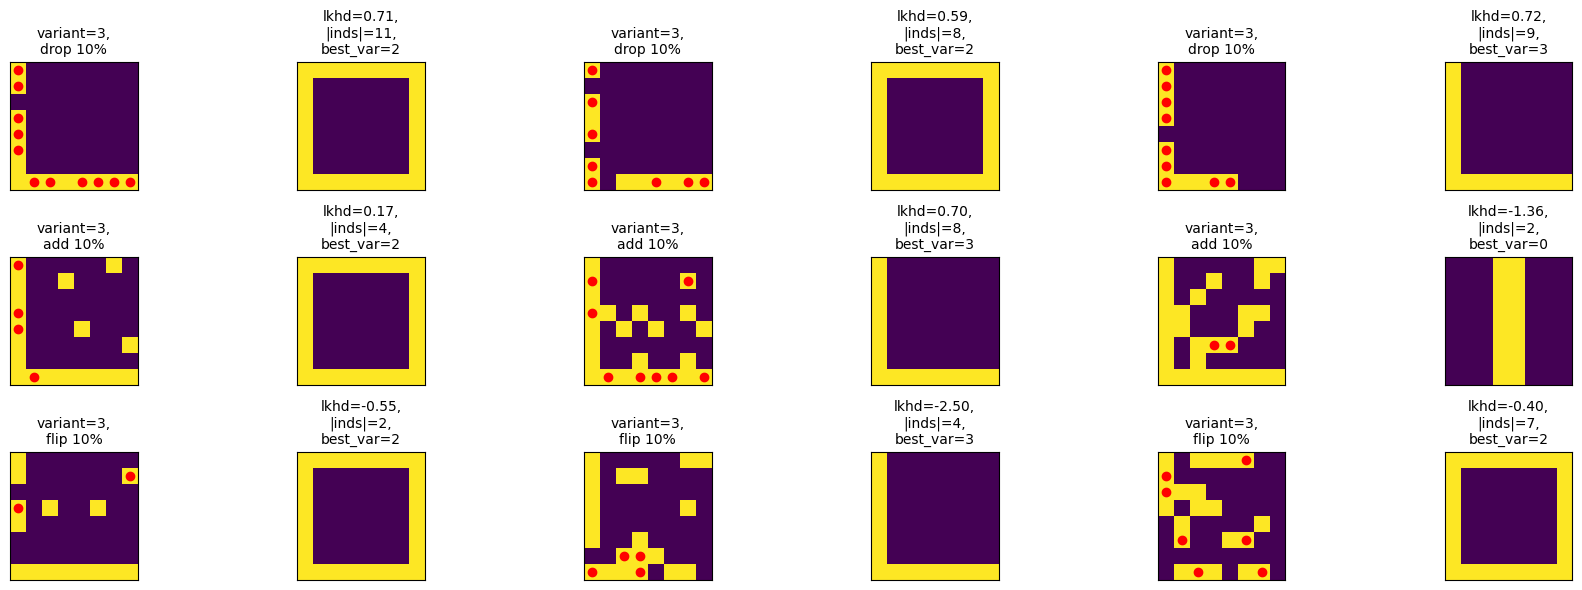

In [557]:
variant = 3
toy_bv = toys[variant].ravel()

method_list = ['drop', 'add', 'flip']
noise_p_list = [0.1, 0.2, 0.3]

fig, axes = plt.subplots(len(method_list), len(noise_p_list) * 2)
fig.set_figwidth(18)
fig.set_figheight(len(method_list) * 2)

for method, method_axes in zip(method_list, axes):
    for noise_p, (ax1, ax2) in zip(noise_p_list, itertools.batched(method_axes, 2)):
        noise_toy_bv = add_noise_to_bv(toy_bv, noise_p, method=method)
        nzb = np.flatnonzero(noise_toy_bv)
        nzb += enc_len8 
        interps = []

        # Try to find subspace on nzb which yield high PDF for variant_encoding,
        # i.e. which looks plausible
        for p in np.linspace(0.9, 0.1, 10):
            boolmap = RNG.choice([False, True], p=[1-p, p], size=len(nzb))

            if np.all(boolmap == False):
                continue
            
            conditioned_nzb = nzb[boolmap]
            scaler = condition_scaler(toy_dataset_scaler8, conditioned_nzb)
            toy_vector_inds = conditioned_nzb - enc_len8
            given_data = noise_toy_bv[toy_vector_inds]
            given_data = scaler.transform([given_data])[0]
            
            sample = sample_mvn_with_conditioning(conditioned_nzb, given_data, cov_mat8)
            
            variant_enc = sample[:enc_len8]
            variant_enc_lkhd = variant_encoding_mvn.logpdf(variant_enc)

            interps.append([variant_enc_lkhd, variant_enc, toy_vector_inds])

        assert interps
        interps.sort(reverse=True)
        best_lkhd, best_variant_enc, best_toy_vector_inds = interps[0]
        
        # Cleanup roundtrip
        best_variant_enc = variant_enc_scaler.inverse_transform([best_variant_enc])[0]
        best_variant = decode_ordinal(best_variant_enc, 0, toys_count-1, method='ohe')
        best_variant_enc = encode_ordinal(best_variant, 0, toys_count-1, method='ohe')
        best_variant_enc = variant_enc_scaler.transform([best_variant_enc])[0]

        sample = sample_mvn_with_conditioning(np.arange(enc_len8), best_variant_enc, cov_mat8)
        
        sample = toy_dataset_scaler8.inverse_transform([sample])[0]
        pixels = sample[enc_len8:]
        pixels = np.where(pixels > .5, 1, 0)

        ax1.imshow(vec_to_square_matrix(noise_toy_bv))
        conditioned_pixels_x = best_toy_vector_inds % toys.shape[1]
        conditioned_pixels_y = best_toy_vector_inds // toys.shape[1]
        ax1.scatter(conditioned_pixels_x, conditioned_pixels_y, color='red')
        ax1.set_title(f'variant={variant},\n{method} {p*100:.0f}%', fontdict=dict(fontsize=10))
        ax1.set_xticks([])
        ax1.set_yticks([])

        ax2.imshow(vec_to_square_matrix(pixels));
        ax2.set_title(f'lkhd={best_lkhd:.2f},\n|inds|={len(best_toy_vector_inds)},\nbest_var={best_variant}', fontdict=dict(fontsize=10))
        ax2.set_xticks([])
        ax2.set_yticks([])

plt.tight_layout();

### 8.5) Selective cond on noisy (ON+OFF), sample variant_enc, estimate lkhd of variant_enc

![](./img/sample-variant-8-05.jpg)

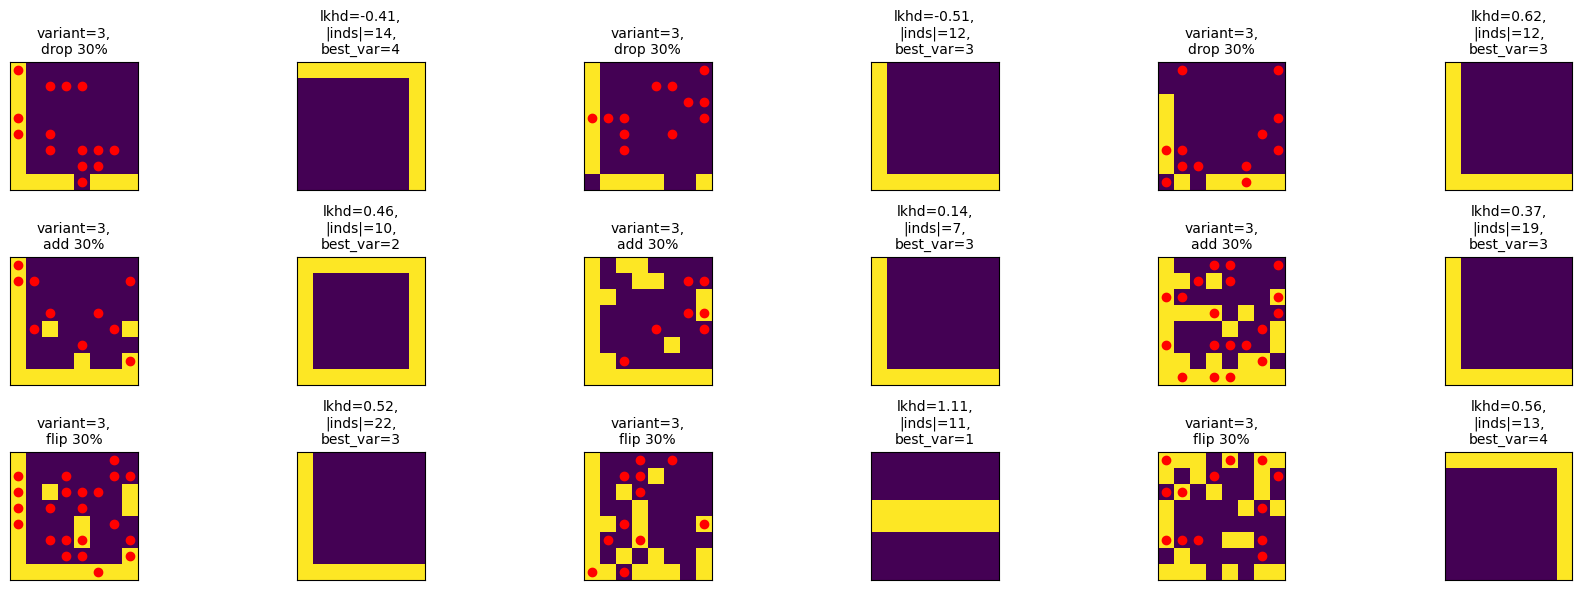

In [558]:
variant = 3
toy_bv = toys[variant].ravel()

method_list = ['drop', 'add', 'flip']
noise_p_list = [0.1, 0.2, 0.3]

fig, axes = plt.subplots(len(method_list), len(noise_p_list) * 2)
fig.set_figwidth(18)
fig.set_figheight(len(method_list) * 2)

for method, method_axes in zip(method_list, axes):
    for noise_p, (ax1, ax2) in zip(noise_p_list, itertools.batched(method_axes, 2)):
        noise_toy_bv = add_noise_to_bv(toy_bv, noise_p, method=method)
        conditioned_var_inds = np.arange(len(noise_toy_bv))
        conditioned_var_inds += enc_len8 
        interps = []

        # Try to find subspace on conditioned_var_inds which yield high PDF for variant_encoding,
        # i.e. which looks plausible
        for p in np.linspace(0.1, 0.3, 10):
            boolmap = RNG.choice([False, True], p=[1-p, p], size=len(conditioned_var_inds))

            if np.all(boolmap == False):
                continue
            
            conditioned_var_inds_hat = conditioned_var_inds[boolmap]
            scaler = condition_scaler(toy_dataset_scaler8, conditioned_var_inds_hat)
            toy_vector_inds = conditioned_var_inds_hat - enc_len8
            given_data = noise_toy_bv[toy_vector_inds]
            given_data = scaler.transform([given_data])[0]
            
            sample = sample_mvn_with_conditioning(conditioned_var_inds_hat, given_data, cov_mat8)
            
            variant_enc = sample[:enc_len8]
            variant_enc_lkhd = variant_encoding_mvn.logpdf(variant_enc)

            interps.append([variant_enc_lkhd, variant_enc, toy_vector_inds])

        assert interps
        interps.sort(reverse=True) # reverse to make variant with max lkhd to be at first pos
        best_lkhd, best_variant_enc, best_toy_vector_inds = interps[0]
        
        # Cleanup roundtrip
        best_variant_enc = variant_enc_scaler.inverse_transform([best_variant_enc])[0]
        best_variant = decode_ordinal(best_variant_enc, 0, toys_count-1, method='ohe')
        best_variant_enc = encode_ordinal(best_variant, 0, toys_count-1, method='ohe')
        best_variant_enc = variant_enc_scaler.transform([best_variant_enc])[0]

        sample = sample_mvn_with_conditioning(np.arange(enc_len8), best_variant_enc, cov_mat8)
        
        sample = toy_dataset_scaler8.inverse_transform([sample])[0]
        pixels = sample[enc_len8:]
        pixels = np.where(pixels > .5, 1, 0)

        ax1.imshow(vec_to_square_matrix(noise_toy_bv))
        conditioned_pixels_x = best_toy_vector_inds % toys.shape[1]
        conditioned_pixels_y = best_toy_vector_inds // toys.shape[1]
        ax1.scatter(conditioned_pixels_x, conditioned_pixels_y, color='red')
        ax1.set_title(f'variant={variant},\n{method} {noise_p*100:.0f}%', fontdict=dict(fontsize=10))
        ax1.set_xticks([])
        ax1.set_yticks([])

        ax2.imshow(vec_to_square_matrix(pixels));
        ax2.set_title(f'lkhd={best_lkhd:.2f},\n|inds|={len(best_toy_vector_inds)},\nbest_var={best_variant}', fontdict=dict(fontsize=10))
        ax2.set_xticks([])
        ax2.set_yticks([])

plt.tight_layout();

### 8.6) ...

In [712]:
def random_pick(pool, p, at_least):
    assert p >= 0 and p <= 1
    l = len(pool)
    assert at_least <= l
    take_count = max(at_least, int(l * p))
    return pool[RNG.choice(l, size=take_count, replace=False)]

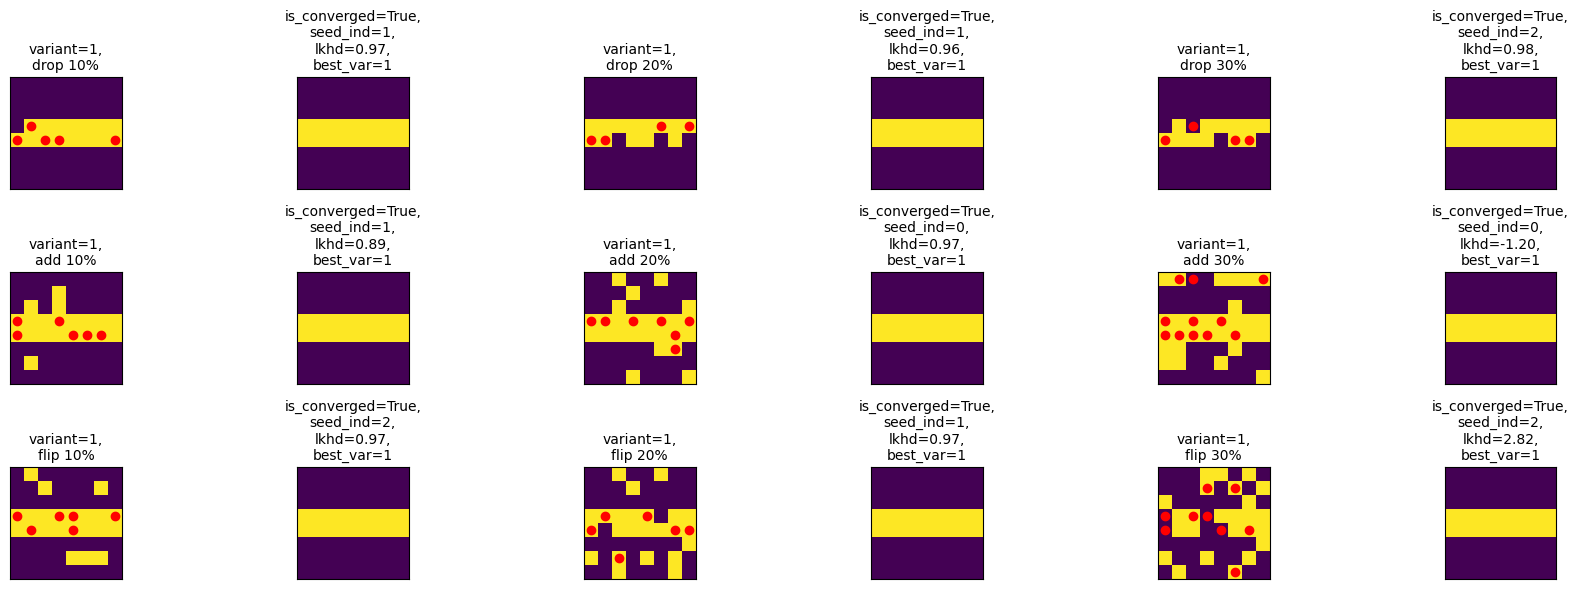

In [993]:
variant = 1
toy_bv = toys[variant].ravel()

method_list = ['drop', 'add', 'flip']
noise_p_list = [0.1, 0.2, 0.3]
# method_list = ['add']
# noise_p_list = [0.1]

fig, axes = plt.subplots(len(method_list), len(noise_p_list) * 2)
axes = axes if axes.ndim == 2 else [axes]
fig.set_figwidth(18)
fig.set_figheight(len(method_list) * 2)

ExecLogEntry = namedtuple('ExecLogEntry', 'noise_toy_bv, variant, conditioned_var_inds, new_var_inds, new_conditioned_var_inds, lkhd, variant_enc, seed_ind')
InterpEntry = namedtuple('InterpEntry', 'is_converged, lkhd, variant_enc, toy_vector_inds, seed_ind')
exec_log = []

for method, method_axes in zip(method_list, axes):
    for noise_p, (ax1, ax2) in zip(noise_p_list, itertools.batched(method_axes, 2)):
        noise_toy_bv = add_noise_to_bv(toy_bv, noise_p, method=method)
        var_inds_pool = set(np.arange(len(toy_bv)) + enc_len8)
        interps = []
        
        for seed_ind in range(3):
            conditioned_var_inds = np.flatnonzero(noise_toy_bv) + enc_len8
            conditioned_var_inds = random_pick(conditioned_var_inds, p=0.2, at_least=2)
            conditioned_var_inds = np.sort(conditioned_var_inds)
            assert len(conditioned_var_inds) > 0
            var_inds_pool -= set(conditioned_var_inds)
            exec_log.append(
                ExecLogEntry(
                    noise_toy_bv=noise_toy_bv, 
                    variant=None, 
                    conditioned_var_inds=np.array([]), 
                    new_var_inds=conditioned_var_inds, 
                    new_conditioned_var_inds=conditioned_var_inds,
                    lkhd=None,
                    variant_enc=None,
                    seed_ind=seed_ind,
                )
            )
            best_variants_tracker = []

            while True:
                assert len(conditioned_var_inds) > 0
                scaler = condition_scaler(toy_dataset_scaler8, conditioned_var_inds)
                toy_vector_inds = conditioned_var_inds - enc_len8
                given_data = noise_toy_bv[toy_vector_inds]
                given_data = scaler.transform([given_data])[0]
                
                sample = sample_mvn_with_conditioning(conditioned_var_inds, given_data, cov_mat8)
                
                variant_enc = sample[:enc_len8]
                variant_enc_lkhd = variant_encoding_mvn.logpdf(variant_enc)
                interp_entry = InterpEntry(
                    is_converged=False, 
                    lkhd=variant_enc_lkhd, 
                    variant_enc=variant_enc, 
                    toy_vector_inds=toy_vector_inds,
                    seed_ind=seed_ind)
                interps.append(interp_entry)
                
                variant_enc_restored = variant_enc_scaler.inverse_transform([variant_enc])[0]
                best_variant = decode_ordinal(variant_enc_restored, 0, toys_count, method='ohe')
                best_variants_tracker = best_variants_tracker[-2:] + [best_variant]

                # Early stop if we get 3 the same variants in sequence. Seems we've converged
                if len(best_variants_tracker) == 3 and np.all(np.isin(best_variants_tracker, best_variant)):
                    # print(f'early stop on variants sequence: {best_variant}, {best_variants_tracker}')
                    interps[-1] = interps[-1]._replace(is_converged=True)
                    break

                # Extend conditioned_var_inds with new elements (new features to test)
                best_variant_enc = encode_ordinal(best_variant, 0, toys_count-1, method='ohe')
                best_variant_enc = variant_enc_scaler.transform([best_variant_enc])[0]
        
                sample = sample_mvn_with_conditioning(np.arange(enc_len8), best_variant_enc, cov_mat8)
            
                sample = toy_dataset_scaler8.inverse_transform([sample])[0]
                pixels = sample[enc_len8:]
                pixels = np.where(pixels > .5, 1, 0)
                var_inds = set(np.flatnonzero(pixels) + enc_len8)
                remaining_var_inds = np.array(list(var_inds_pool & var_inds))

                # Early stop if we can't find any new var index (seems we've checked already most of available var_inds_pool)
                if len(remaining_var_inds) == 0:
                    # print(f'early stop on no remaining_var_inds')
                    break

                new_var_inds = random_pick(remaining_var_inds, 0.1, at_least=1)
                assert len(new_var_inds) > 0
                old_conditioned_var_inds = conditioned_var_inds
                conditioned_var_inds = np.sort(np.r_[conditioned_var_inds, new_var_inds])
                assert Counter(conditioned_var_inds).most_common(1)[0][1] == 1 # ensure that conditioned_var_inds doesn't have dups
                var_inds_pool -= set(conditioned_var_inds)
                exec_log.append(
                    ExecLogEntry(
                        noise_toy_bv=noise_toy_bv, 
                        variant=best_variant, 
                        conditioned_var_inds=old_conditioned_var_inds, 
                        new_var_inds=new_var_inds, 
                        new_conditioned_var_inds=conditioned_var_inds,
                        lkhd=variant_enc_lkhd,
                        variant_enc=variant_enc,
                        seed_ind=seed_ind
                    )
                )
                
        assert interps
        interps.sort(key=lambda i: (not i.is_converged, -i.lkhd))
        # interps.sort(reverse=True)
        is_converged, best_lkhd, best_variant_enc, best_toy_vector_inds, seed_ind = interps[0]
        
        # Cleanup roundtrip
        best_variant_enc = variant_enc_scaler.inverse_transform([best_variant_enc])[0]
        best_variant = decode_ordinal(best_variant_enc, 0, toys_count-1, method='ohe')
        best_variant_enc = encode_ordinal(best_variant, 0, toys_count-1, method='ohe')
        best_variant_enc = variant_enc_scaler.transform([best_variant_enc])[0]

        sample = sample_mvn_with_conditioning(np.arange(enc_len8), best_variant_enc, cov_mat8)
        
        sample = toy_dataset_scaler8.inverse_transform([sample])[0]
        pixels = sample[enc_len8:]
        pixels = np.where(pixels > .5, 1, 0)

        ax1.imshow(vec_to_square_matrix(noise_toy_bv))
        conditioned_pixels_x = best_toy_vector_inds % toys.shape[1]
        conditioned_pixels_y = best_toy_vector_inds // toys.shape[1]
        ax1.scatter(conditioned_pixels_x, conditioned_pixels_y, color='red')
        ax1.set_title(f'variant={variant},\n{method} {noise_p*100:.0f}%', fontdict=dict(fontsize=10))
        ax1.set_xticks([])
        ax1.set_yticks([])

        ax2.imshow(vec_to_square_matrix(pixels));
        ax2.set_title(f'is_converged={is_converged},\nseed_ind={seed_ind},\nlkhd={best_lkhd:.2f},\nbest_var={best_variant}', fontdict=dict(fontsize=10))
        ax2.set_xticks([])
        ax2.set_yticks([])

plt.tight_layout();

In [994]:
# fig, axes = plt.subplots(len(exec_log), 3)
# fig.set_figheight(len(exec_log)*2)

# for exec_log_entry, (ax1, ax2, ax3) in zip(exec_log, axes):
#     noise_toy_bv, variant, conditioned_var_inds, new_var_inds, new_conditioned_var_inds, lkhd, variant_enc, seed_ind = exec_log_entry

#     # Situation before step
#     ax1.imshow(vec_to_square_matrix(noise_toy_bv))
#     ax1.set_xticks([])
#     ax1.set_yticks([])
#     cond_pixel_inds = conditioned_var_inds - enc_len8
#     xx = cond_pixel_inds % toys.shape[1]
#     yy = cond_pixel_inds // toys.shape[1]
#     ax1.scatter(xx, yy, color='red')

#     # Decision made during step
#     if not variant is None: 
#         ax2.imshow(toys[variant])
#     else:
#         ax2.imshow(vec_to_square_matrix(np.zeros_like(noise_toy_bv)))

#     ax2.set_xticks([])
#     ax2.set_yticks([])
#     new_pixel_inds = new_var_inds - enc_len8
#     new_pixel_xx = new_pixel_inds % toys.shape[1]
#     new_pixel_yy = new_pixel_inds // toys.shape[1]
#     ax2.scatter(new_pixel_xx, new_pixel_yy, color='green')
#     lkhd = '-' if lkhd is None else f'{lkhd:.2f}'
#     variant_enc = [] if variant_enc is None else variant_enc_scaler.inverse_transform([variant_enc])[0]
#     variant_enc = ', '.join([f'{x:.2f}' for x in variant_enc])
#     ax2.set_title(f'seed_ind={seed_ind},\nlkhd={lkhd},\nvar. enc=[{variant_enc}]', fontdict=dict(fontsize=10))

#     # Resulting situation at the end of a step 
#     ax3.imshow(vec_to_square_matrix(noise_toy_bv))
#     ax3.set_xticks([])
#     ax3.set_yticks([])
#     new_cond_pixel_inds = new_conditioned_var_inds - enc_len8
#     xx = new_cond_pixel_inds % toys.shape[1]
#     yy = new_cond_pixel_inds // toys.shape[1]
#     ax3.scatter(xx, yy, color='red')
#     ax3.scatter(new_pixel_xx, new_pixel_yy, color='green')

# fig.tight_layout()

# Hier norm distr

In [57]:
def calc_seq_ipxy(sequences, si_ind_dict):
    res = []  # transcript of sequences with full interpolation by xy 
        
    for sequence in sequences:
        xy_sequence = get_xy_sequence(sequence, si_ind_dict)
        xy_sequence_fwd = np.roll(xy_sequence, -1, axis=0)
        vec_sequence = xy_sequence_fwd - xy_sequence
        vec_sequence[-1,:] = 0 # get rid of reciprocal vector which connects tail to tip
        vec_len_sequence = np.linalg.norm(vec_sequence, axis=1)
        vec_len_sequence_nozero = np.where(vec_len_sequence != 0, vec_len_sequence, 1e-6) # prevent 0 len vectors
        norm_vec_sequence = (vec_sequence.T / vec_len_sequence_nozero).T
        vec_len_sequence = np.round(vec_len_sequence, decimals=0).astype(int)
        
        assert len(sequence) == vec_sequence.shape[0]
        assert len(sequence) == vec_len_sequence.shape[0]
        assert len(sequence) == norm_vec_sequence.shape[0]
        
        for pt, pt_to, norm_vec, vec_len in zip(xy_sequence, xy_sequence_fwd, norm_vec_sequence, vec_len_sequence):
            if vec_len <= 0:
                continue

            pts = pt + (np.arange(vec_len) * norm_vec[np.newaxis,:].T).T # path interpolation
            pts = np.round(pts, decimals=0).astype(int)
            res.append(pts)
            res.append(pt_to)

    assert res
    res = np.vstack(res)
    return res

def calc_seq_bv(seq_xy):
    assert np.all((seq_xy >= 0) & (seq_xy < config.sample_size))
    ind_seq = (seq_xy @ np.array([1, config.sample_size])).astype(int)
    bitmap_vec = np.zeros((config.sample_size, config.sample_size), dtype='f').ravel()
    bitmap_vec[ind_seq] = 1
    return bitmap_vec

In [58]:
IMAGES_COUNT = 1000
images = df_train_images[df_train_images.value == '5'][:IMAGES_COUNT]

BLOCK_SIZE = 8
block_coords = []

for i in range(0, config.sample_size, BLOCK_SIZE):
    for j in range(0, config.sample_size, BLOCK_SIZE):
        coords = np.s_[i:i+BLOCK_SIZE,j:j+BLOCK_SIZE]
        block_coords.append(coords)

blocks_count = len(block_coords)
assert blocks_count == 256

macroblock_dataset = []
block_dataset = [[] for _ in range(blocks_count)]

for image in tqdm(images.itertuples(), total=len(images)):
    sequences = pickle.loads(image.inner_sequences)
    si_ind_dict = pickle.loads(image.inner_si_ind_dict)
    ipxy = calc_seq_ipxy(sequences, si_ind_dict)
    bv = calc_seq_bv(ipxy).reshape(config.sample_size, -1) # bitmap vec
    macroblock_row = []

    for block_ind, coords in enumerate(block_coords):
        block = bv[coords].ravel()
        assert len(block) == 64
        assert np.all(np.isin(block, [0,1]))
        macroblock_row.append(block.sum())
        block_dataset[block_ind].append(block)

    macroblock_dataset.append(macroblock_row)

macroblock_dataset_orig = np.array(macroblock_dataset)
block_dataset_orig = np.array(block_dataset)

  0%|          | 0/898 [00:00<?, ?it/s]

In [59]:
macroblock_scaler = StandardScaler(with_mean=True, with_std=True)
macroblock_dataset = macroblock_scaler.fit_transform(macroblock_dataset_orig);

block_scalers = []
block_dataset = block_dataset_orig.copy()

for ind, blocks in enumerate(block_dataset):
    block_scaler = StandardScaler()
    block_dataset[ind] = block_scaler.fit_transform(blocks)
    block_scalers.append(block_scaler)
    # assert ind != 62

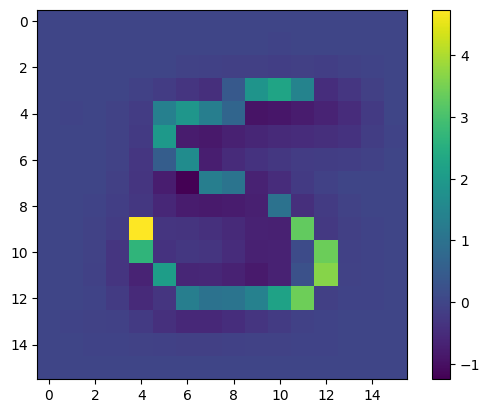

In [60]:
ind = RNG.choice(len(macroblock_dataset))
image = macroblock_dataset[ind]

plt.imshow(vec_to_square_matrix(image))
plt.colorbar();

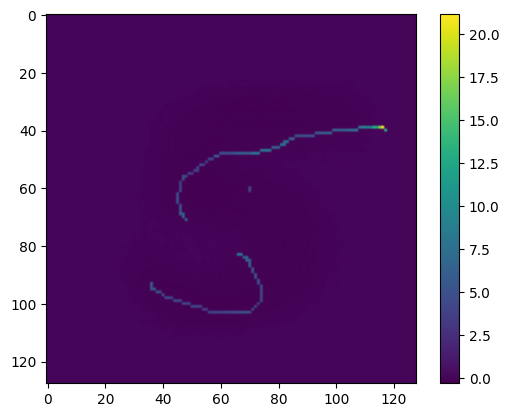

In [61]:
image = np.zeros((config.sample_size, config.sample_size))
dataset_row_ind = RNG.choice(len(block_dataset))

for block_ind, blocks in enumerate(block_dataset):
    where_to = block_coords[block_ind]
    block_sample = blocks[dataset_row_ind]
    # if np.any(block_sample>10):
    #     assert False
    image[where_to] = block_sample.reshape(BLOCK_SIZE, -1)

plt.imshow(image)
plt.colorbar();

156.17391485652604


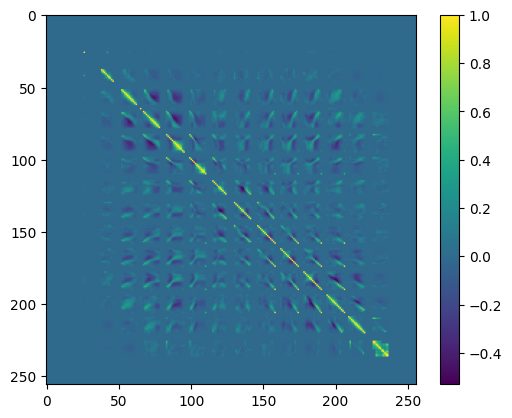

In [62]:
Σ_macro = np.cov(macroblock_dataset, rowvar=False)
print(np.linalg.trace(Σ_macro))
plt.imshow(Σ_macro)
plt.colorbar();

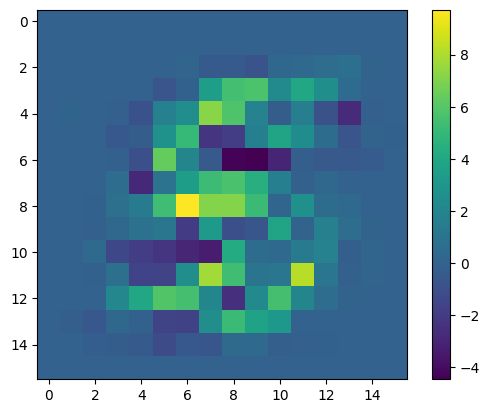

In [63]:
sample = RNG.multivariate_normal(
    # mean=macroblock_means,
    mean=np.zeros(len(Σ_macro)),
    cov=Σ_macro)
# sample += macroblock_means
sample = macroblock_scaler.inverse_transform(sample[np.newaxis,:])[0]
plt.imshow(vec_to_square_matrix(sample))#, cmap='turbo')
plt.colorbar();

In [64]:
Σ_contextual_block_size = len(Σ_macro) + BLOCK_SIZE**2
Σ_blocks1 = []
Σ_blocks2 = []
chol_blocks1 = []
chol_blocks2 = []

make_positive_definite1 = np.eye(Σ_contextual_block_size) * 0.000001
make_positive_definite2 = np.eye(BLOCK_SIZE**2) * 0.000001

for block_ind, block in tqdm(enumerate(block_dataset), total=len(block_dataset)):
    concat_dataset = np.c_[macroblock_dataset, block]
    Σ_block = np.cov(concat_dataset, rowvar=False)
    assert np.all(np.isclose(Σ_block[:len(Σ_macro),:len(Σ_macro)], Σ_macro))
    Σ_block += make_positive_definite1
    Σ_blocks1.append(Σ_block)
    chol_block = np.linalg.cholesky(Σ_block)
    chol_blocks1.append(chol_block)

    Σ_block = np.cov(block, rowvar=False)
    Σ_block += make_positive_definite2
    Σ_blocks2.append(Σ_block)
    chol_block = np.linalg.cholesky(Σ_block)
    chol_blocks2.append(chol_block)

  0%|          | 0/256 [00:00<?, ?it/s]

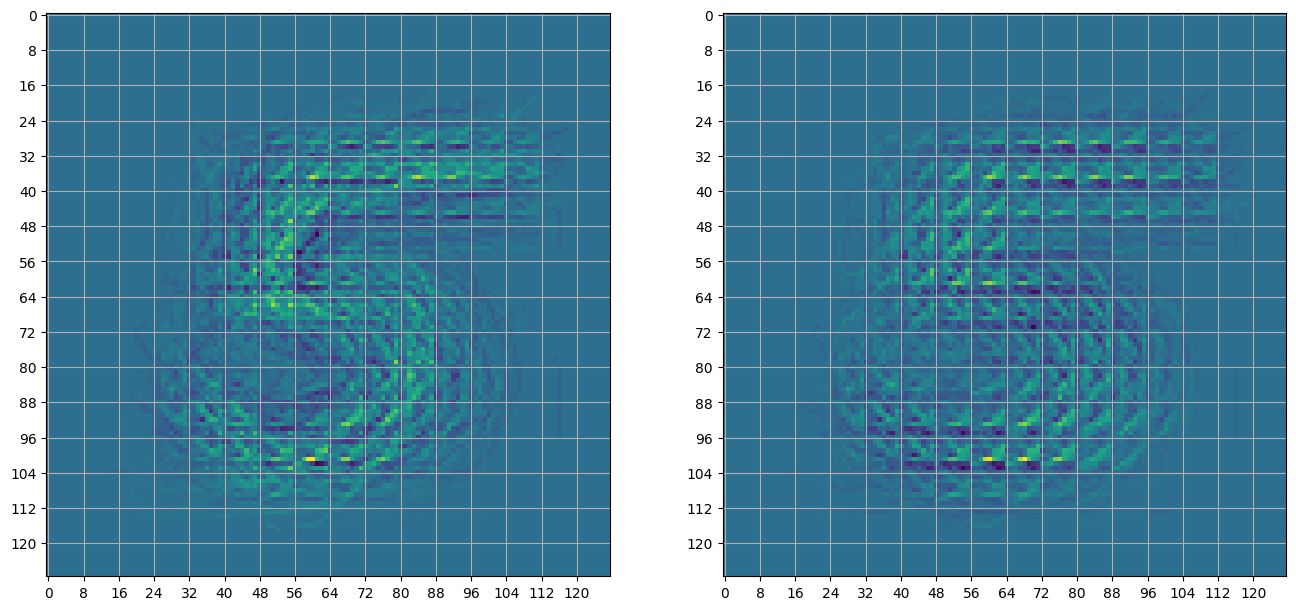

In [65]:
image1 = np.zeros((config.sample_size, config.sample_size))
image2 = np.zeros((config.sample_size, config.sample_size))

seed1 = RNG.multivariate_normal(
    mean=np.zeros(Σ_contextual_block_size),
    cov=np.eye(Σ_contextual_block_size))

seed2 = seed1[len(Σ_macro):]

for block_ind, (chol_block1, chol_block2) in enumerate(zip(chol_blocks1, chol_blocks2)):
    where_to = block_coords[block_ind]
    
    block_sample_raw = chol_block1 @ seed1
    block_sample = block_sample_raw[len(Σ_macro):]
    # block_sample += block_means[block_ind]
    block_sample = block_scalers[block_ind].inverse_transform(block_sample[np.newaxis,:])[0]
    block_sample = block_sample.reshape(BLOCK_SIZE, -1)
    image1[where_to] = block_sample

    block_sample = chol_block2 @ seed2
    # block_sample += block_means[block_ind]
    block_sample = block_scalers[block_ind].inverse_transform(block_sample[np.newaxis,:])[0]
    block_sample = block_sample.reshape(BLOCK_SIZE, -1)
    image2[where_to] = block_sample

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
fig.set_figheight(8)

# binarize = lambda i: np.where(i > 0.5, 1, 0)
binarize = lambda i: i

ax1.imshow(binarize(image1))
ax1.grid(True)
ax1.set_xticks(np.arange(0, config.sample_size, BLOCK_SIZE))
ax1.set_yticks(np.arange(0, config.sample_size, BLOCK_SIZE))

ax2.imshow(binarize(image2))
ax2.grid(True);
ax2.set_xticks(np.arange(0, config.sample_size, BLOCK_SIZE))
ax2.set_yticks(np.arange(0, config.sample_size, BLOCK_SIZE));

# plt.colorbar(shrink=0.8);

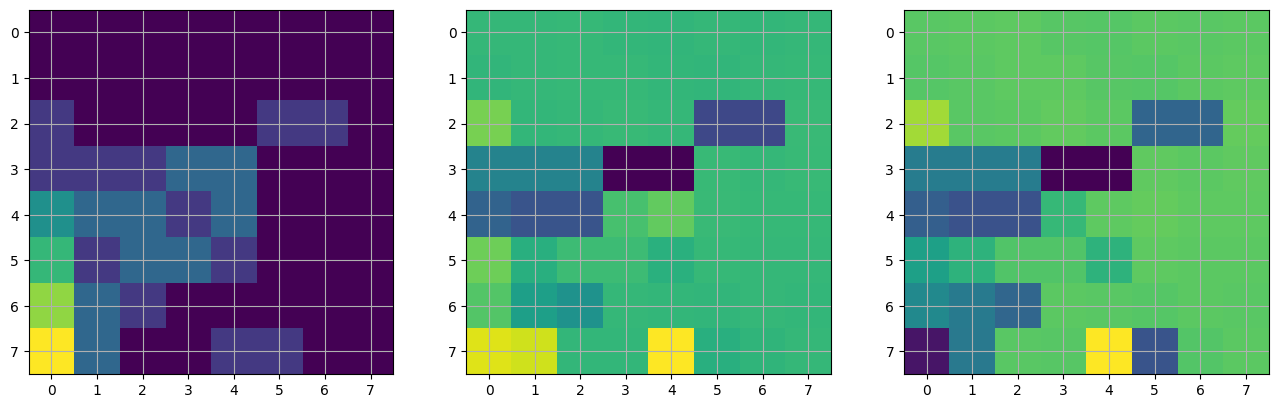

In [66]:
# seed1 = RNG.multivariate_normal(
#     mean=np.zeros(Σ_contextual_block_size),
#     cov=np.eye(Σ_contextual_block_size))

# seed2 = seed1[len(Σ_macro):]

i = 7
j = 6
block_ind = BLOCK_SIZE*i+j

chol_block1 = chol_blocks1[block_ind]
block_sample_raw = chol_block1 @ seed1
block_sample = block_sample_raw[len(Σ_macro):]
# block_sample += block_means[block_ind]
block_sample = block_scalers[block_ind].inverse_transform(block_sample[np.newaxis,:])[0]
image1 = block_sample.reshape(BLOCK_SIZE, -1)

chol_block2 = chol_blocks2[block_ind]
block_sample = chol_block2 @ seed2
# block_sample += block_means[block_ind]
block_sample = block_scalers[block_ind].inverse_transform(block_sample[np.newaxis,:])[0]
image2 = block_sample.reshape(BLOCK_SIZE, -1)

fig, (ax0, ax1, ax2) = plt.subplots(1, 3)
fig.set_figwidth(16)
fig.set_figheight(8)

ax0.imshow(vec_to_square_matrix(block_scalers[block_ind].mean_))
ax0.grid(True)
ax0.set_xticks(np.arange(BLOCK_SIZE))
ax0.set_yticks(np.arange(BLOCK_SIZE));

ax1.imshow(image1)
ax1.grid(True)
ax1.set_xticks(np.arange(BLOCK_SIZE))
ax1.set_yticks(np.arange(BLOCK_SIZE));

im = ax2.imshow(image2)
ax2.grid(True);
ax2.set_xticks(np.arange(BLOCK_SIZE))
ax2.set_yticks(np.arange(BLOCK_SIZE));
# fig.colorbar(im, ax=ax2, shrink=0.6);

In [67]:
np.unique_counts(block_dataset_orig[block_ind][:,24])

UniqueCountsResult(values=array([0., 1.], dtype=float32), counts=array([897,   1]))

In [68]:
np.round(vec_to_square_matrix(block_scalers[block_ind].mean_), 3)

array([[0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.001, 0.   , 0.   , 0.   , 0.   , 0.001, 0.001, 0.   ],
       [0.001, 0.001, 0.001, 0.002, 0.002, 0.   , 0.   , 0.   ],
       [0.003, 0.002, 0.002, 0.001, 0.002, 0.   , 0.   , 0.   ],
       [0.004, 0.001, 0.002, 0.002, 0.001, 0.   , 0.   , 0.   ],
       [0.006, 0.002, 0.001, 0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.007, 0.002, 0.   , 0.   , 0.001, 0.001, 0.   , 0.   ]])

In [69]:
np.round(vec_to_square_matrix(block_scalers[block_ind].scale_), 3)

array([[1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ],
       [1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ],
       [0.033, 1.   , 1.   , 1.   , 1.   , 0.033, 0.033, 1.   ],
       [0.033, 0.033, 0.033, 0.047, 0.047, 1.   , 1.   , 1.   ],
       [0.058, 0.047, 0.047, 0.033, 0.047, 1.   , 1.   , 1.   ],
       [0.067, 0.033, 0.047, 0.047, 0.033, 1.   , 1.   , 1.   ],
       [0.074, 0.047, 0.033, 1.   , 1.   , 1.   , 1.   , 1.   ],
       [0.081, 0.047, 1.   , 1.   , 0.033, 0.033, 1.   , 1.   ]])

In [70]:
np.round(image1, 2)

array([[-0.  ,  0.  ,  0.  , -0.  , -0.  ,  0.  , -0.  ,  0.  ],
       [-0.  , -0.  ,  0.  ,  0.  , -0.  , -0.  ,  0.  ,  0.  ],
       [ 0.02, -0.  ,  0.  ,  0.  ,  0.  , -0.08, -0.08,  0.  ],
       [-0.04, -0.04, -0.04, -0.12, -0.12,  0.  ,  0.  ,  0.  ],
       [-0.06, -0.07, -0.07,  0.01,  0.02,  0.  ,  0.  ,  0.  ],
       [ 0.02, -0.01,  0.  ,  0.  , -0.01,  0.  ,  0.  ,  0.  ],
       [ 0.01, -0.02, -0.03,  0.  , -0.  , -0.  , -0.  , -0.  ],
       [ 0.05,  0.05, -0.  , -0.  ,  0.06, -0.01, -0.  ,  0.  ]])

In [71]:
np.round(image2, 2)

array([[-0.  ,  0.  ,  0.  , -0.  , -0.  ,  0.  , -0.  ,  0.  ],
       [-0.  , -0.  ,  0.  ,  0.  , -0.  , -0.  ,  0.  ,  0.  ],
       [ 0.01, -0.  ,  0.  ,  0.  ,  0.  , -0.05, -0.05,  0.  ],
       [-0.04, -0.04, -0.04, -0.1 , -0.1 ,  0.  ,  0.  ,  0.  ],
       [-0.06, -0.06, -0.06, -0.01,  0.  ,  0.  ,  0.  ,  0.  ],
       [-0.02, -0.01, -0.  , -0.  , -0.01,  0.  ,  0.  ,  0.  ],
       [-0.03, -0.04, -0.05,  0.  , -0.  , -0.  , -0.  , -0.  ],
       [-0.09, -0.04, -0.  , -0.  ,  0.03, -0.06, -0.  ,  0.  ]])

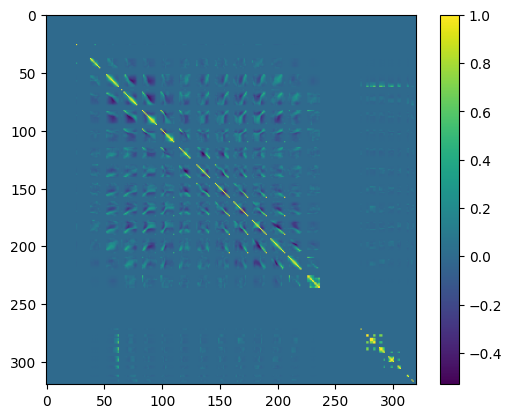

In [72]:
Σ_block = Σ_blocks1[block_ind]
plt.imshow(Σ_block)
plt.colorbar()